# Paper figures (size 25) — **enhanced uncertainty conventions**

This notebook mirrors `paper_figures_draft_size25.ipynb` (**same run grid, all paper sparsities × init scales, task-routed + shared + single baseline, geometry**) but adopts explicit **SEM across participants (network seeds)** where Seaborn aggregates:

- **Transfer `error_diff`:** `catplot(kind="swarm")` (participant dots) plus overlaid `pointplot` with `errorbar="se"` and `capsize`; other panels use `pointplot` / `bar` with `errorbar="se"` where applicable.
- **Transfer / accuracy / ablation / protocol** plots: SEM + colored points via `hue="condition"` (transfer) where a single series per category is shown
- **PC count (`n_pcs_99`)**: participant-level rows with `errorbar="se"` (no pre-aggregate to a single mean with `errorbar=None`)
- **Principal angles (task-routed)**: existing mean ± SEM overlay; points use `hue="condition"` for consistency
- **Geometry (2D/3D PCA)**: unchanged from the draft (qualitative snapshots, not aggregated SEM)

**Does not** replace the draft notebook — use this version when you want error bars to be explicitly SEM rather than Seaborn’s default bootstrap CI.


In [21]:
# 1) Setup

import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print

SIMILARITY_ORDER = ["same", "near", "far"]
SIMILARITY_PALETTE = {"same": "green", "near": "orange", "far": "blue"}

PHASE_ORDER = ["post_A", "post_B", "post_A2"]

# We keep the same global ordering conventions as the existing notebooks.
INIT_SCALE_ORDER = [0.001, 0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0, 2]
SPARSITY_ORDER = ["no_comms", "0.1", "0.3", "0.5", "0.7", "0.9", "1.0", "single_module"]

# Minimal paper grid
PAPER_INIT_SCALES = [0.001, 0.01, 0.1, 1, 2]
PAPER_SPARSITIES = ["no_comms", "0.5", "1.0"]

project_root = Path(os.getcwd()).resolve()
while not (project_root / "a1b2").exists():
    if project_root == project_root.parent:
        raise RuntimeError("Project root (containing a1b2) not found.")
    project_root = project_root.parent

sys.path.insert(0, str(project_root))
os.chdir(project_root)

from a1b2.utils.run_config import build_run_id
from a1b2.analysis import transfer_interference as ann
from a1b2.analysis.paper_single_baseline import (
    ROUTING_HUE_ORDER,
    ROUTING_PALETTE,
    broadcast_baseline_sparsity,
    select_single_baseline_df,
)
from a1b2.analysis.transfer_interference import prepare_pca_shared_three_phase
from a1b2.utils.figure_utils import plot_split_stim_postA_postB_postA2, get_axis_limits

sim_folder = (project_root / "data" / "simulations")
config_path = (project_root / "a1b2" / "models" / "experiments.json")
settings = json.loads(config_path.read_text())

sns.set_theme(context="notebook", style="whitegrid")

print("Project root:", project_root)
print("Simulations folder:", sim_folder)
print("Config:", config_path)


Project root: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular
Simulations folder: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations
Config: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/a1b2/models/experiments.json


In [22]:
# 2) Select runs for the paper grid (task-routed default + shared ablation)

TARGET_ARCH = "two_module_rnn"
TARGET_DIM_HIDDEN = 25
TARGET_NB_STEPS = 2
TARGET_COMMON_READOUT = True
TARGET_COMMON_INPUT = False


def sparsity_label_from_condition(c):
    sp = c.get("sparsity", 1.0)
    if sp == 0 or "no_comms" in c.get("name", ""):
        return "no_comms"
    sf = float(sp)
    return "1.0" if np.isclose(sf, 1.0) else str(sf)


def init_scale_from_condition(c):
    init_scale = c.get("init_scale", None)
    return float(1.0 if init_scale is None else init_scale)


def select_conditions(input_routing: str):
    conds = []
    for c in settings["conditions"]:
        if c.get("arch") != TARGET_ARCH:
            continue
        if c.get("dim_hidden") != TARGET_DIM_HIDDEN:
            continue
        if c.get("nb_steps", 1) != TARGET_NB_STEPS:
            continue
        if c.get("common_readout", True) is not TARGET_COMMON_READOUT:
            continue
        if c.get("common_input", False) is not TARGET_COMMON_INPUT:
            continue
        if c.get("input_routing", "shared") != input_routing:
            continue

        sp_label = sparsity_label_from_condition(c)
        init_scale = init_scale_from_condition(c)

        if sp_label not in PAPER_SPARSITIES:
            continue
        if init_scale not in PAPER_INIT_SCALES:
            continue

        run_id = build_run_id(c)
        path = sim_folder / run_id
        conds.append(
            {
                **c,
                "run_id": run_id,
                "path": str(path),
                "path_exists": path.exists(),
                "sparsity_label": sp_label,
                "init_scale": init_scale,
            }
        )

    df = pd.DataFrame(conds)
    if df.empty:
        return df

    df["sparsity_label"] = pd.Categorical(df["sparsity_label"], categories=SPARSITY_ORDER, ordered=True)
    df = df.sort_values(["sparsity_label", "init_scale", "name"]).reset_index(drop=True)
    return df


task_df = select_conditions("task_routed")
shared_df = select_conditions("shared")

print("Task-routed selected:", len(task_df), "valid:", int(task_df["path_exists"].sum()))
print("Shared selected:", len(shared_df), "valid:", int(shared_df["path_exists"].sum()))

display(task_df[["name", "run_id", "init_scale", "sparsity_label", "path_exists"]])
display(shared_df[["name", "run_id", "init_scale", "sparsity_label", "path_exists"]])

single_df = select_single_baseline_df(
    settings,
    sim_folder,
    two_module_dim_hidden=TARGET_DIM_HIDDEN,
    paper_sparsities=PAPER_SPARSITIES,
    paper_init_scales=PAPER_INIT_SCALES,
    sparsity_order=SPARSITY_ORDER,
    build_run_id=build_run_id,
    sparsity_label_from_condition=sparsity_label_from_condition,
    init_scale_from_condition=init_scale_from_condition,
    target_nb_steps=TARGET_NB_STEPS,
    target_common_readout=TARGET_COMMON_READOUT,
    target_common_input=TARGET_COMMON_INPUT,
)

print(
    "Single-module baseline:",
    len(single_df),
    "valid:",
    int(single_df["path_exists"].sum()) if len(single_df) else 0,
)
if len(single_df):
    display(single_df[["name", "run_id", "init_scale", "sparsity_label", "path_exists"]])


Task-routed selected: 24 valid: 13
Shared selected: 24 valid: 13


,name,run_id,init_scale,sparsity_label,path_exists
0,two_module_rnn_25_task_routed_no_comms_nb2_ini...,two_module_rnn_25_task_routed_no_comms_nb2_ini...,0.001,no_comms,True
1,two_module_rnn_25_task_routed_no_comms_nb2_ini...,two_module_rnn_25_task_routed_no_comms_nb2_ini...,0.010,no_comms,True
2,two_module_rnn_25_task_routed_no_comms_nb2_ini...,two_module_rnn_25_task_routed_no_comms_nb2_ini...,0.010,no_comms,False
3,two_module_rnn_25_task_routed_no_comms_nb2_ini...,two_module_rnn_25_task_routed_no_comms_nb2_ini...,0.100,no_comms,True
4,two_module_rnn_25_task_routed_no_comms_nb2_ini...,two_module_rnn_25_task_routed_no_comms_nb2_ini...,0.100,no_comms,False
5,two_module_rnn_25_task_routed_no_comms_nb2,two_module_rnn_25_task_routed_no_comms_nb2_nb2...,1.000,no_comms,True
6,two_module_rnn_25_task_routed_no_comms_nb2_inp...,two_module_rnn_25_task_routed_no_comms_nb2_inp...,1.000,no_comms,False
7,two_module_rnn_25_task_routed_no_comms_nb2_init2,two_module_rnn_25_task_routed_no_comms_nb2_ini...,2.000,no_comms,True
8,two_module_rnn_25_task_routed_sp05_nb2_init0.001,two_module_rnn_25_task_routed_sp05_nb2_init0.0...,0.001,0.5,False
9,two_module_rnn_25_task_routed_sp05_nb2_init0.01,two_module_rnn_25_task_routed_sp05_nb2_init0.0...,0.010,0.5,True


,name,run_id,init_scale,sparsity_label,path_exists
0,two_module_rnn_25_no_comms_nb2_init0.001,two_module_rnn_25_no_comms_nb2_init0.001_nb2_s...,0.001,no_comms,True
1,two_module_rnn_25_no_comms_nb2_init0.01,two_module_rnn_25_no_comms_nb2_init0.01_nb2_sh...,0.010,no_comms,True
2,two_module_rnn_25_no_comms_nb2_init0.01_input_...,two_module_rnn_25_no_comms_nb2_init0.01_input_...,0.010,no_comms,False
3,two_module_rnn_25_no_comms_nb2_init0.1,two_module_rnn_25_no_comms_nb2_init0.1_nb2_sha...,0.100,no_comms,True
4,two_module_rnn_25_no_comms_nb2_init0.1_input_only,two_module_rnn_25_no_comms_nb2_init0.1_input_o...,0.100,no_comms,False
5,two_module_rnn_25_no_comms_nb2,two_module_rnn_25_no_comms_nb2_nb2_shared_sp0_...,1.000,no_comms,True
6,two_module_rnn_25_no_comms_nb2_input_only,two_module_rnn_25_no_comms_nb2_input_only_nb2_...,1.000,no_comms,False
7,two_module_rnn_25_no_comms_nb2_init2,two_module_rnn_25_no_comms_nb2_init2_nb2_share...,2.000,no_comms,True
8,two_module_rnn_25_sp05_nb2_init0.001,two_module_rnn_25_sp05_nb2_init0.001_nb2_share...,0.001,0.5,False
9,two_module_rnn_25_sp05_nb2_init0.01,two_module_rnn_25_sp05_nb2_init0.01_nb2_shared...,0.010,0.5,True


Single-module baseline: 5 valid: 5


,name,run_id,init_scale,sparsity_label,path_exists
0,single_module_rnn_50_nb2_init0.001,single_module_rnn_50_nb2_init0.001_nb2_shared_...,0.001,1.0,True
1,single_module_rnn_50_nb2_init0.01,single_module_rnn_50_nb2_init0.01_nb2_shared_s...,0.010,1.0,True
2,single_module_rnn_50_nb2_init0.1,single_module_rnn_50_nb2_init0.1_nb2_shared_sp...,0.100,1.0,True
3,single_module_rnn_50_nb2,single_module_rnn_50_nb2_nb2_shared_sp1_sep_cr...,1.000,1.0,True
4,single_module_rnn_50_nb2_init2,single_module_rnn_50_nb2_init2_nb2_shared_sp1_...,2.000,1.0,True


In [23]:
# 3) Load ANN data + build participant-level dataframes (transfer, phase accuracies, rep metrics, angles)

from collections import defaultdict


def load_all_ann_data(df_runs: pd.DataFrame):
    out = {}
    for _, row in df_runs[df_runs["path_exists"]].iterrows():
        run_id = row["run_id"]
        path = Path(row["path"])
        ann_data = ann.load_ann_data(path)
        out[run_id] = {
            "data": ann_data,
            "init_scale": float(row["init_scale"]),
            "sparsity_label": str(row["sparsity_label"]),
        }
    return out


def compute_metrics(all_ann_data: dict):
    transfer_records = []
    accuracy_records = []
    rep_records = []
    angles_records = []

    for run_id, bundle in all_ann_data.items():
        ann_data = bundle["data"]
        init_scale = bundle["init_scale"]
        sp_label = bundle["sparsity_label"]

        # principal angles (A vs B)
        angles_df = ann.get_principal_angles(ann_data)
        angles_df = angles_df.copy()
        angles_df["run_id"] = run_id
        angles_df["init_scale"] = init_scale
        angles_df["sparsity_label"] = sp_label
        angles_records.append(angles_df)

        # participant-level metrics
        for cond_name, entries in ann_data.items():
            if cond_name not in SIMILARITY_ORDER:
                continue
            for entry in entries:
                pid = str(entry.get("participant"))

                acc = np.asarray(entry["accuracy"])
                if acc.ndim == 3:
                    cond_idx = SIMILARITY_ORDER.index(cond_name)
                    acc_cond = acc[cond_idx]
                else:
                    acc_cond = acc

                # Transfer (error_diff): init_B - final_A1
                if acc_cond.ndim >= 2 and acc_cond.shape[0] >= 2:
                    A1_acc = acc_cond[0, 1::2]
                    B_acc = acc_cond[1, 1::2]
                    if len(A1_acc) >= 6 and len(B_acc) >= 6:
                        final_A1 = float(np.mean(A1_acc[-6:]))
                        init_B = float(np.mean(B_acc[:6]))
                        transfer_records.append(
                            {
                                "run_id": run_id,
                                "init_scale": init_scale,
                                "sparsity_label": sp_label,
                                "condition": cond_name,
                                "participant": pid,
                                "error_diff": init_B - final_A1,
                            }
                        )

                # Phase accuracies
                n_ph = acc_cond.shape[0]
                for ph in range(min(3, n_ph)):
                    phase_name = PHASE_ORDER[ph]
                    accuracy_records.append(
                        {
                            "run_id": run_id,
                            "init_scale": init_scale,
                            "sparsity_label": sp_label,
                            "condition": cond_name,
                            "participant": pid,
                            "phase": phase_name,
                            "mean_accuracy": float(np.nanmean(acc_cond[ph])),
                        }
                    )

                # Representation metrics (combined/core/comms) per phase
                for phase_idx, phase_name in enumerate(PHASE_ORDER):
                    if f"hiddens_post_phase_{phase_idx}" not in entry:
                        continue
                    for path in ("combined", "core", "comms"):
                        try:
                            hids = ann._get_last_step_geometry_hids(entry, phase_idx, path=path)
                        except Exception:
                            continue
                        metrics = ann.compute_state_representation_metrics(
                            hids, variance_thresholds=(0.95, 0.99), top_k=2
                        )
                        row = {
                            "run_id": run_id,
                            "init_scale": init_scale,
                            "sparsity_label": sp_label,
                            "condition": cond_name,
                            "participant": pid,
                            "phase": phase_name,
                            "pathway": path,
                            "var_topk": float(metrics["var_topk"]),
                        }
                        for thr, n in metrics["n_components"].items():
                            row[f"n_pcs_{int(thr*100)}"] = int(n)
                        rep_records.append(row)

    transfer_df = pd.DataFrame(transfer_records)
    acc_df = pd.DataFrame(accuracy_records)
    rep_df = pd.DataFrame(rep_records)
    angles_all = pd.concat(angles_records, ignore_index=True) if angles_records else pd.DataFrame()

    return transfer_df, acc_df, rep_df, angles_all


all_task = load_all_ann_data(task_df)
all_shared = load_all_ann_data(shared_df)

transfer_task, acc_task, rep_task, angles_task = compute_metrics(all_task)
transfer_shared, acc_shared, rep_shared, angles_shared = compute_metrics(all_shared)
all_single = load_all_ann_data(single_df) if len(single_df) else {}
transfer_single, acc_single, rep_single, angles_single = compute_metrics(all_single)

print("task: transfer", transfer_task.shape, "acc", acc_task.shape, "rep", rep_task.shape, "angles", angles_task.shape)
print("shared: transfer", transfer_shared.shape, "acc", acc_shared.shape, "rep", rep_shared.shape, "angles", angles_shared.shape)
print(
    "single: transfer",
    transfer_single.shape,
    "acc",
    acc_single.shape,
    "rep",
    rep_single.shape,
    "angles",
    angles_single.shape,
)


task: transfer (2970, 6) acc (8910, 7) rep (8910, 10) angles (2970, 6)
shared: transfer (3046, 6) acc (9138, 7) rep (9138, 10) angles (3046, 6)
single: transfer (1049, 6) acc (3147, 7) rep (3147, 10) angles (1049, 6)


## Figure 1 — Transfer / accuracy (task-routed)

**Transfer:** `kind="swarm"` so every participant is one dot (non-overlapping), with **mean ± SEM** overlaid (`pointplot`, `errorbar="se"`). This matches the earlier *strip + point* demo idea; use **swarm** here instead of **strip** for clearer separation when **n** is moderate. (Very large **n** can make swarm slow—switch to `kind="strip"` with jitter if needed.)

**Accuracy:** still `kind="point"` with `errorbar="se"` (two phases, hue). Subtitle gives global **n** min/max for transfer.


,sparsity_label,init_scale,condition,n
0,0.5,0.010,far,101
1,0.5,0.010,near,101
2,0.5,0.010,same,103
3,0.5,0.100,far,101
4,0.5,0.100,near,101
5,0.5,0.100,same,103
6,0.5,1.000,far,101
7,0.5,1.000,near,101
8,0.5,1.000,same,103
9,1.0,0.001,far,23


/tmp/ipykernel_3438060/3278221039.py:49: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_3438060/3278221039.py:49: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_3438060/3278221039.py:49: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_3438060/3278221039.py:49: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib

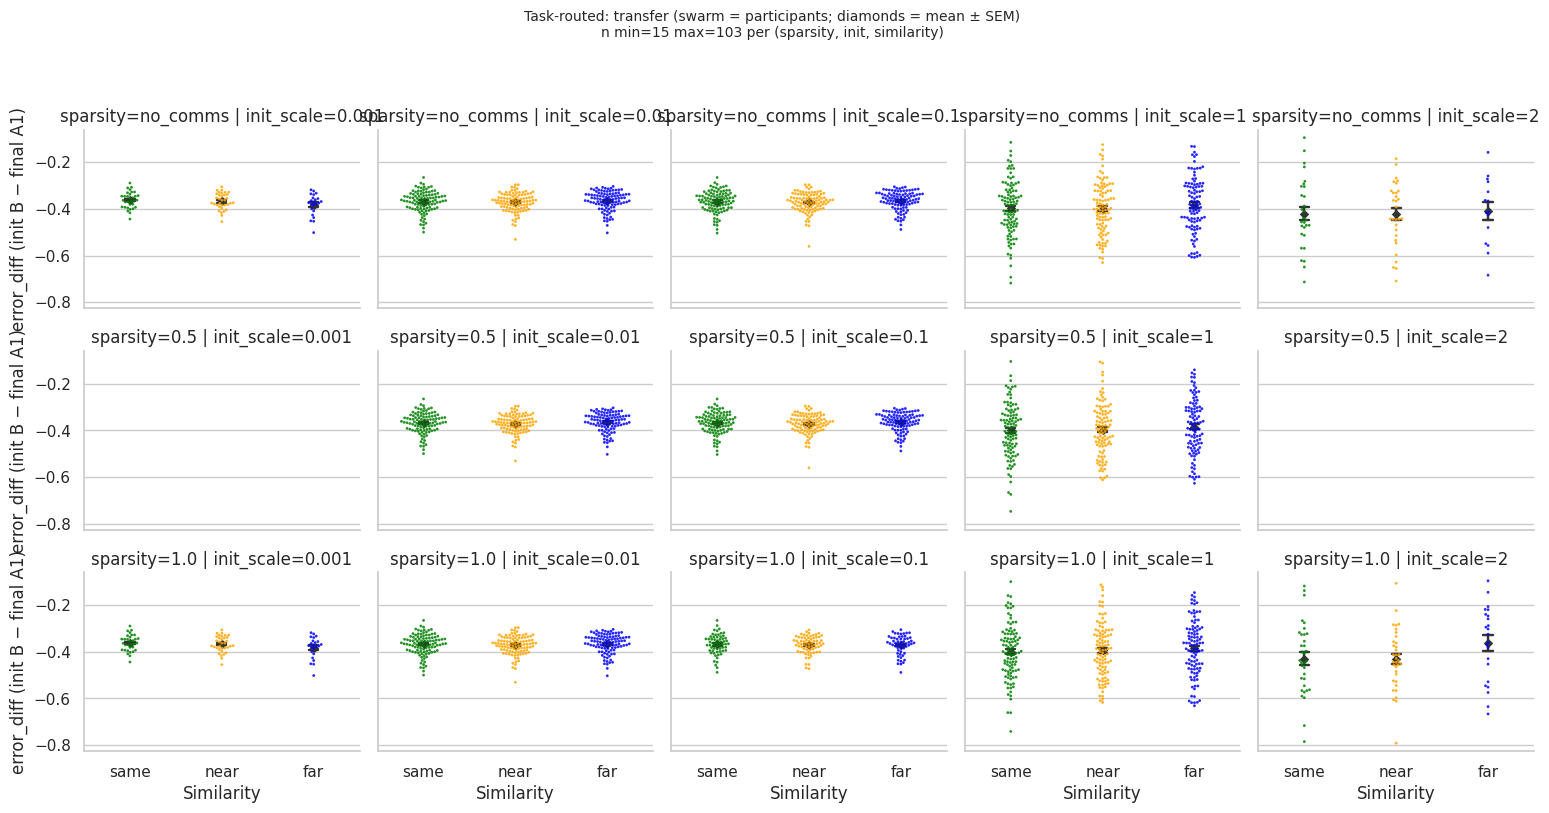

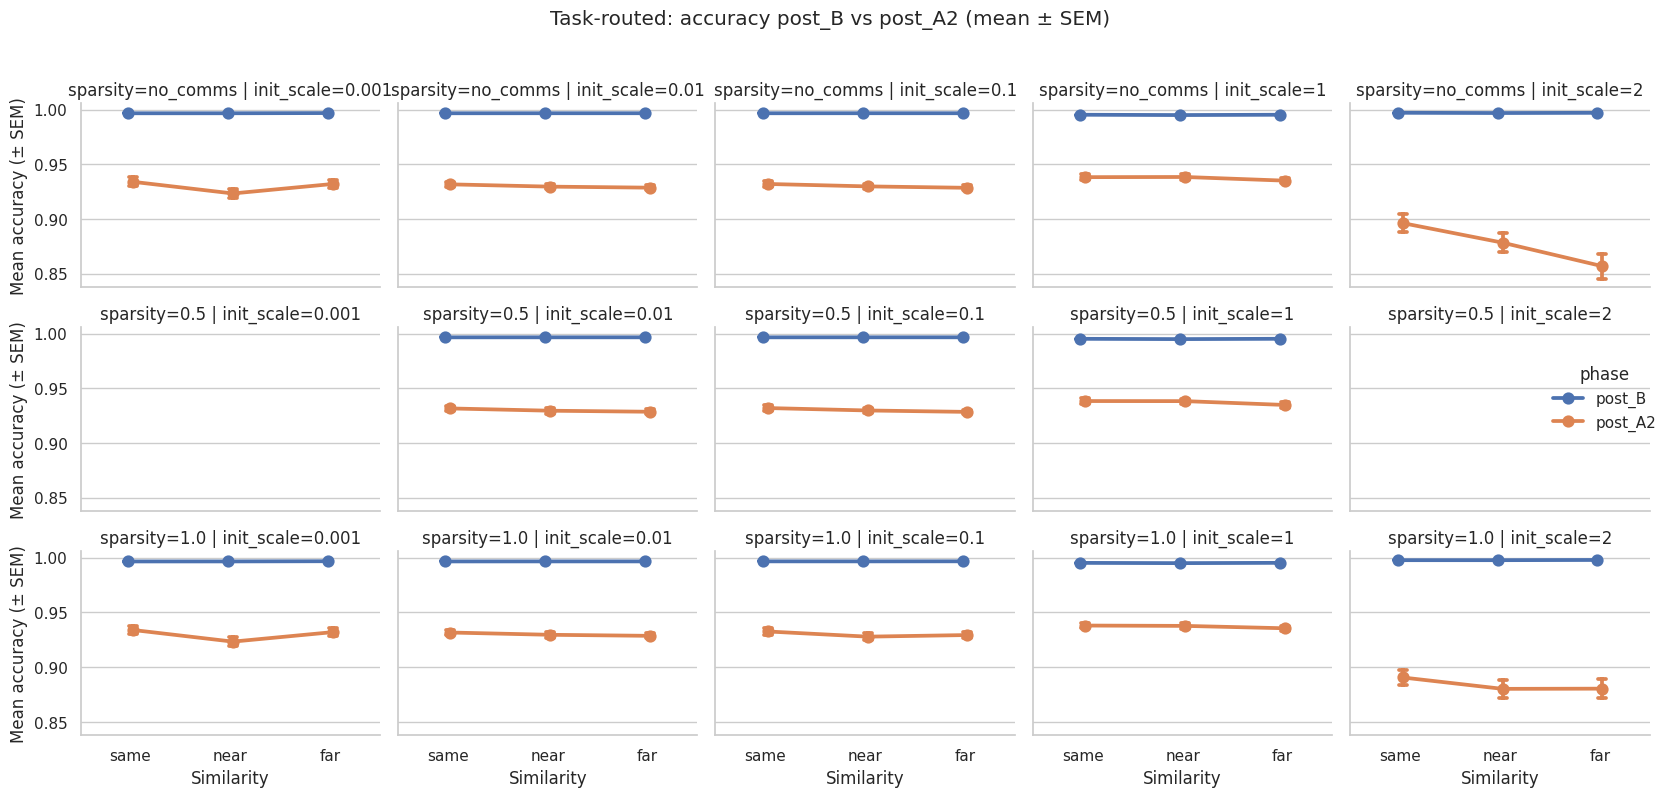

In [24]:
def _facet_orders():
    init_order = [s for s in PAPER_INIT_SCALES if s in INIT_SCALE_ORDER]
    sp_order = [s for s in PAPER_SPARSITIES if s in SPARSITY_ORDER]
    return init_order, sp_order


init_order, sp_order = _facet_orders()

# Effective sample sizes (participants per facet)
if not transfer_task.empty:
    _n = (
        transfer_task.groupby(["sparsity_label", "init_scale", "condition"], observed=True)["participant"]
        .nunique()
        .reset_index(name="n")
    )
    display(_n.sort_values(["sparsity_label", "init_scale", "condition"]))

# Transfer / interference — swarm (participant-level points) + mean ± SEM overlay
if not transfer_task.empty:
    tr = transfer_task.copy()
    tr["init_scale"] = tr["init_scale"].astype(float)
    g = sns.catplot(
        data=tr,
        x="condition",
        y="error_diff",
        hue="condition",
        hue_order=SIMILARITY_ORDER,
        col="init_scale",
        row="sparsity_label",
        col_order=init_order,
        row_order=sp_order,
        kind="swarm",
        dodge=False,
        order=SIMILARITY_ORDER,
        palette=SIMILARITY_PALETTE,
        size=2.0,
        linewidth=0,
        alpha=0.85,
        height=2.6,
        aspect=1.2,
        legend=False,
    )
    for i, row_name in enumerate(sp_order):
        for j, col_name in enumerate(init_order):
            ax = g.axes[i, j]
            sub = tr[(tr["sparsity_label"] == row_name) & (tr["init_scale"] == col_name)]
            if sub.empty:
                continue
            sns.pointplot(
                data=sub,
                x="condition",
                y="error_diff",
                order=SIMILARITY_ORDER,
                ax=ax,
                color="0.2",
                errorbar="se",
                capsize=0.1,
                markers="D",
                linestyles="",
                scale=0.65,
                legend=False,
            )
    g.set_axis_labels("Similarity", "error_diff (init B − final A1)")
    g.set_titles(row_template="sparsity={row_name}", col_template="init_scale={col_name}")
    nn = tr.groupby(["sparsity_label", "init_scale", "condition"], observed=True)["participant"].nunique()
    g.fig.suptitle(
        "Task-routed: transfer (swarm = participants; diamonds = mean ± SEM)\n"
        f"n min={int(nn.min())} max={int(nn.max())} per (sparsity, init, similarity)",
        y=1.04,
        fontsize=10,
    )
    plt.tight_layout()
    plt.show()

# Accuracy in key phases
if not acc_task.empty:
    sub = acc_task[acc_task["phase"].isin(["post_B", "post_A2"])].copy()
    sub["init_scale"] = sub["init_scale"].astype(float)
    g = sns.catplot(
        data=sub,
        x="condition",
        y="mean_accuracy",
        hue="phase",
        col="init_scale",
        row="sparsity_label",
        col_order=init_order,
        row_order=sp_order,
        kind="point",
        dodge=True,
        order=SIMILARITY_ORDER,
        hue_order=["post_B", "post_A2"],
        height=2.6,
        aspect=1.2,
        errorbar="se",
        capsize=0.08,
    )
    g.set_axis_labels("Similarity", "Mean accuracy (± SEM)")
    g.set_titles(row_template="sparsity={row_name}", col_template="init_scale={col_name}")
    g.fig.suptitle("Task-routed: accuracy post_B vs post_A2 (mean ± SEM)", y=1.02)
    plt.tight_layout()
    plt.show()


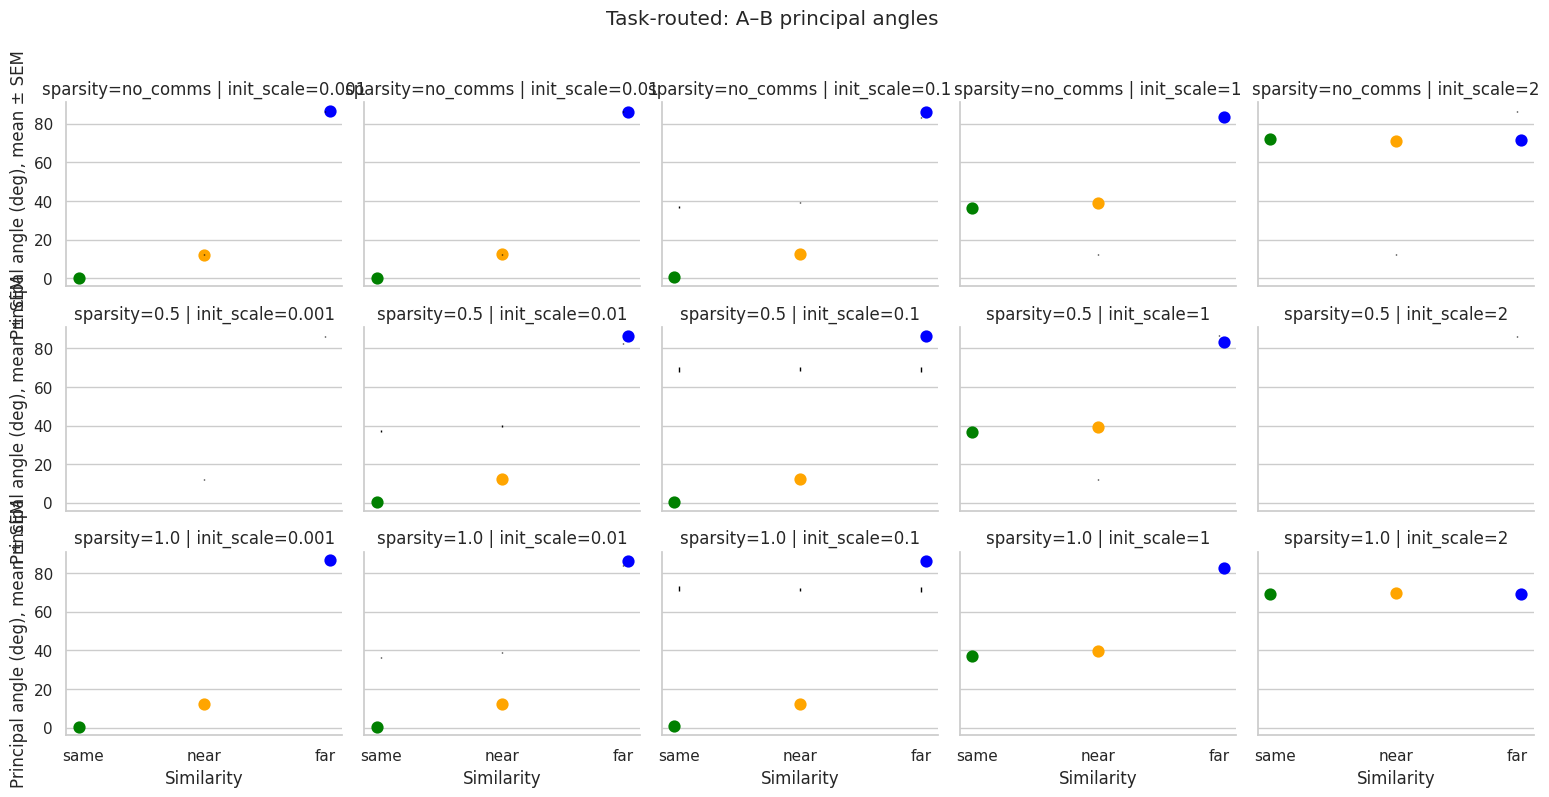

In [25]:
if not angles_task.empty:
    ang = angles_task.copy()
    ang["init_scale"] = ang["init_scale"].astype(float)

    ang_agg = (
        ang.groupby(["sparsity_label", "init_scale", "condition"], as_index=False)["principal_angle_between"]
        .agg(["mean", "sem"])
        .reset_index()
        .rename(columns={"mean": "angle_mean", "sem": "angle_sem"})
    )

    g = sns.catplot(
        data=ang_agg,
        x="condition",
        y="angle_mean",
        hue="condition",
        hue_order=SIMILARITY_ORDER,
        col="init_scale",
        row="sparsity_label",
        col_order=init_order,
        row_order=sp_order,
        kind="point",
        dodge=True,
        order=SIMILARITY_ORDER,
        palette=SIMILARITY_PALETTE,
        height=2.6,
        aspect=1.2,
        legend=False,
    )

    for ax, (_, subdf) in zip(g.axes.flat, ang_agg.groupby(["sparsity_label", "init_scale"], sort=False)):
        x = np.arange(len(SIMILARITY_ORDER))
        subdf = subdf.set_index("condition").reindex(SIMILARITY_ORDER)
        ax.errorbar(x, subdf["angle_mean"].values, yerr=subdf["angle_sem"].values, fmt="none", c="black", lw=1)

    g.set_axis_labels("Similarity", "Principal angle (deg), mean ± SEM")
    g.set_titles(row_template="sparsity={row_name}", col_template="init_scale={col_name}")
    g.fig.suptitle("Task-routed: A–B principal angles", y=1.02)
    plt.tight_layout()
    plt.show()


## Figure 3 — PC count `n_pcs_99` (task-routed)

**Participant-level** rows in each `catplot`; `errorbar="se"` (draft pre-averaged then `errorbar=None`).


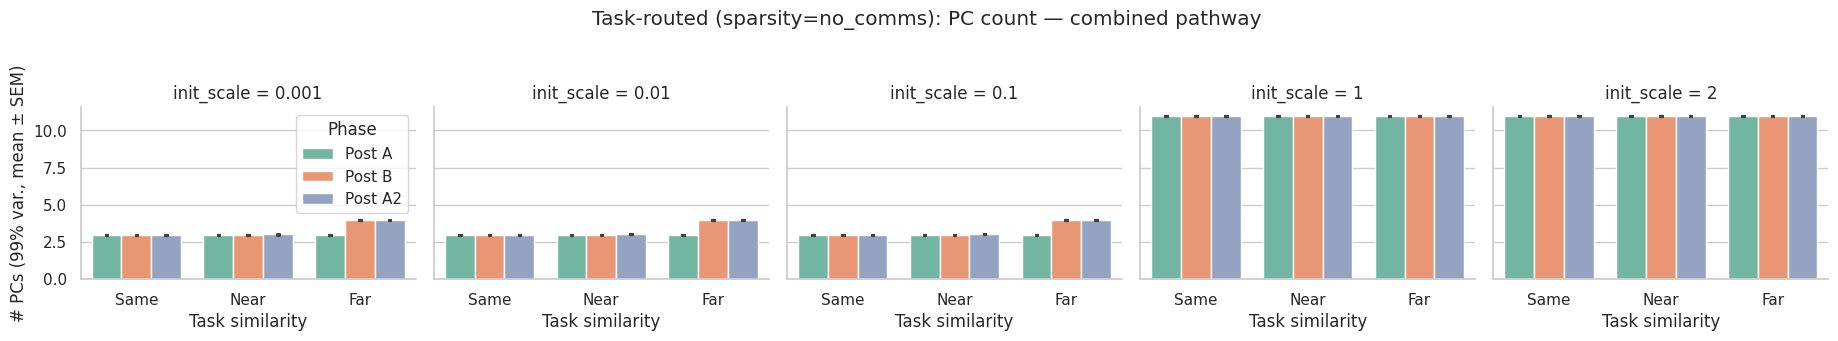

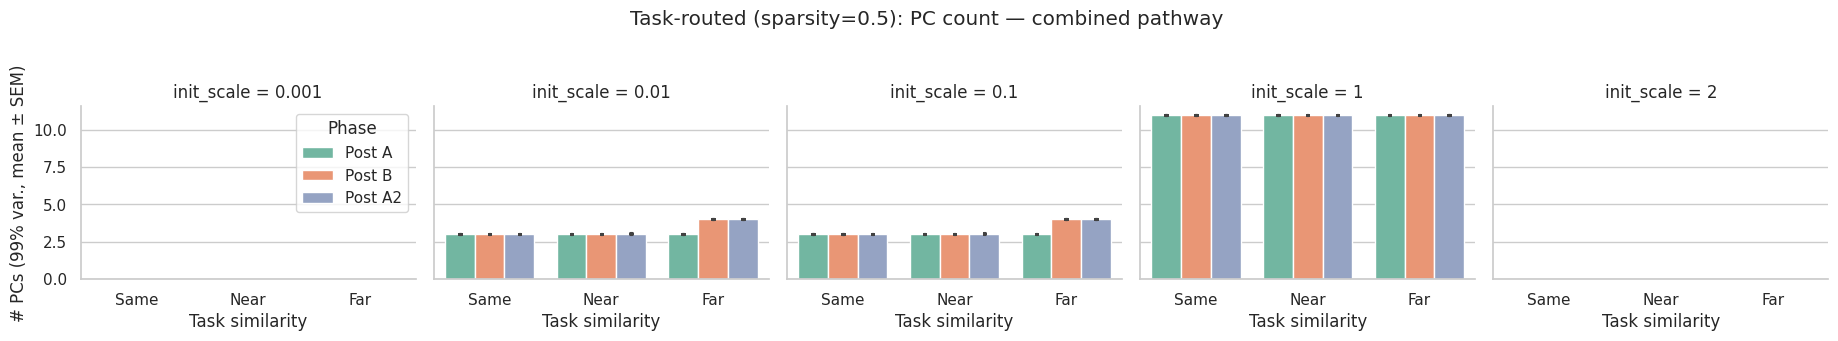

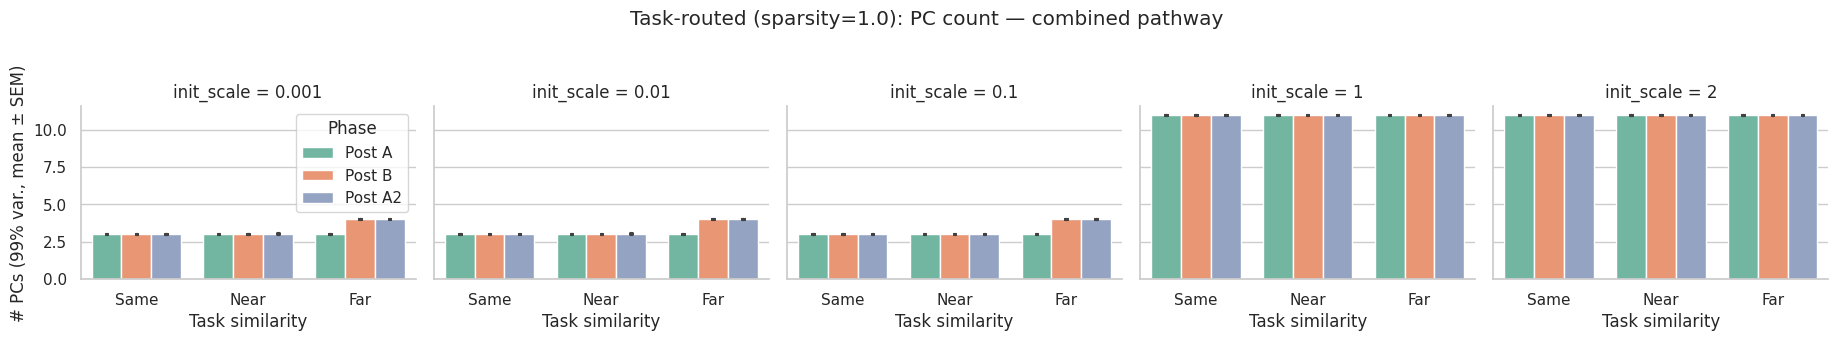

In [26]:
if not rep_task.empty:
    pc = rep_task[(rep_task["pathway"] == "combined")].copy()
    pc["init_scale"] = pc["init_scale"].astype(float)
    pc["phase"] = pd.Categorical(pc["phase"], categories=PHASE_ORDER, ordered=True)
    pc["condition"] = pd.Categorical(pc["condition"], categories=SIMILARITY_ORDER, ordered=True)

    phase_labels = {"post_A": "Post A", "post_B": "Post B", "post_A2": "Post A2"}
    cond_labels = {"same": "Same", "near": "Near", "far": "Far"}
    pc["phase_plot"] = pc["phase"].map(phase_labels)
    pc["condition_plot"] = pc["condition"].map(cond_labels)

    for sp in PAPER_SPARSITIES:
        sub = pc[pc["sparsity_label"].astype(str) == sp].copy()
        if sub.empty or "n_pcs_99" not in sub.columns:
            continue

        g = sns.catplot(
            data=sub,
            x="condition_plot",
            y="n_pcs_99",
            hue="phase_plot",
            col="init_scale",
            col_order=init_order,
            kind="bar",
            order=["Same", "Near", "Far"],
            hue_order=["Post A", "Post B", "Post A2"],
            palette="Set2",
            height=3.2,
            aspect=1.15,
            legend_out=False,
            errorbar="se",
            capsize=0.04,
        )
        g.set_axis_labels("Task similarity", "# PCs (99% var., mean ± SEM)")
        g.set_titles("init_scale = {col_name}")
        if g._legend is not None:
            g._legend.set_title("Phase")
        g.fig.suptitle(f"Task-routed (sparsity={sp}): PC count — combined pathway", y=1.06)
        plt.tight_layout()
        plt.show()


## Figure 4 — 2D PCA geometry snapshots (task-routed)

Same as draft: first matching run per (sparsity, `init_scale`), single example trajectory per panel.


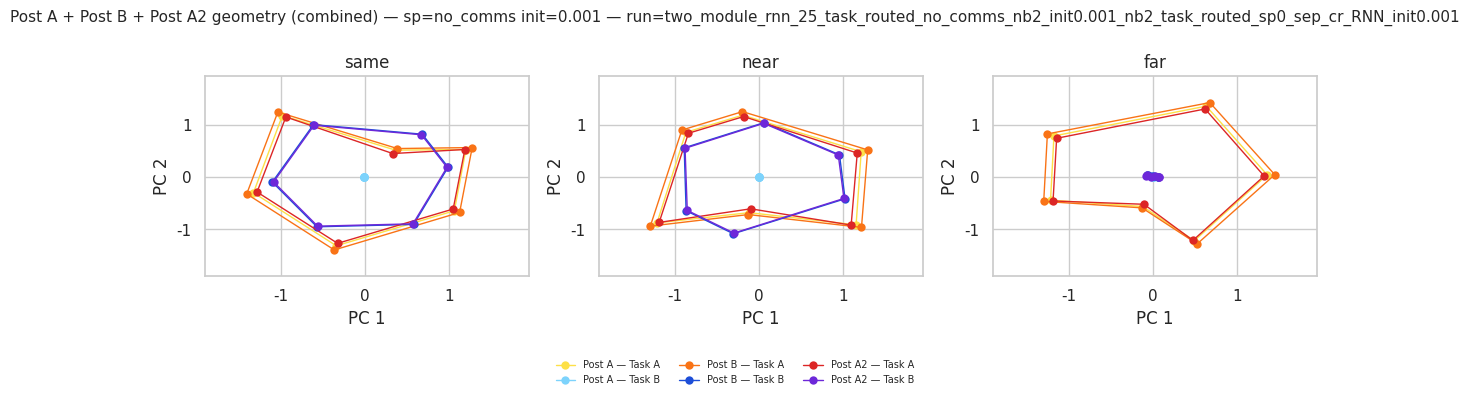

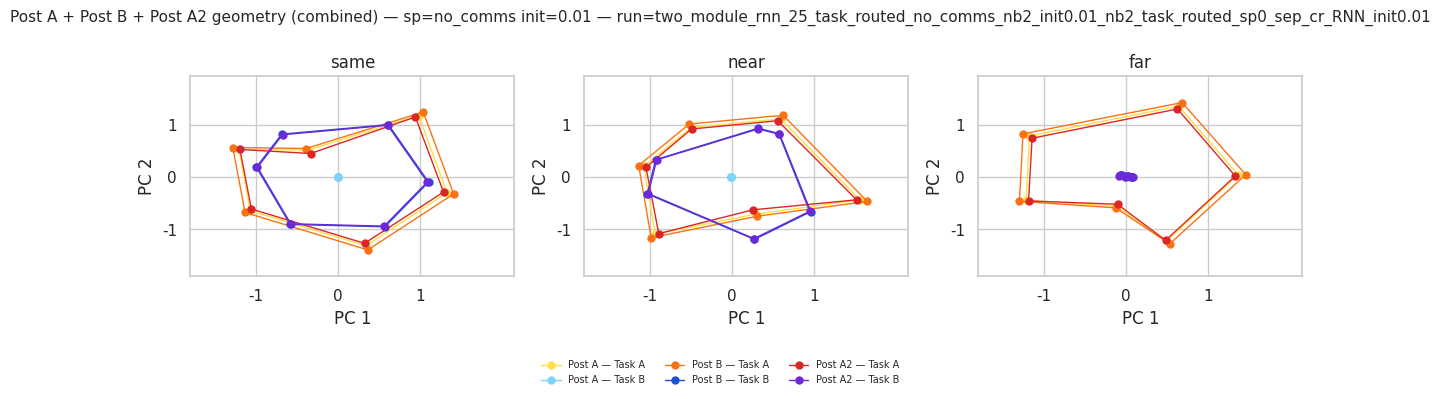

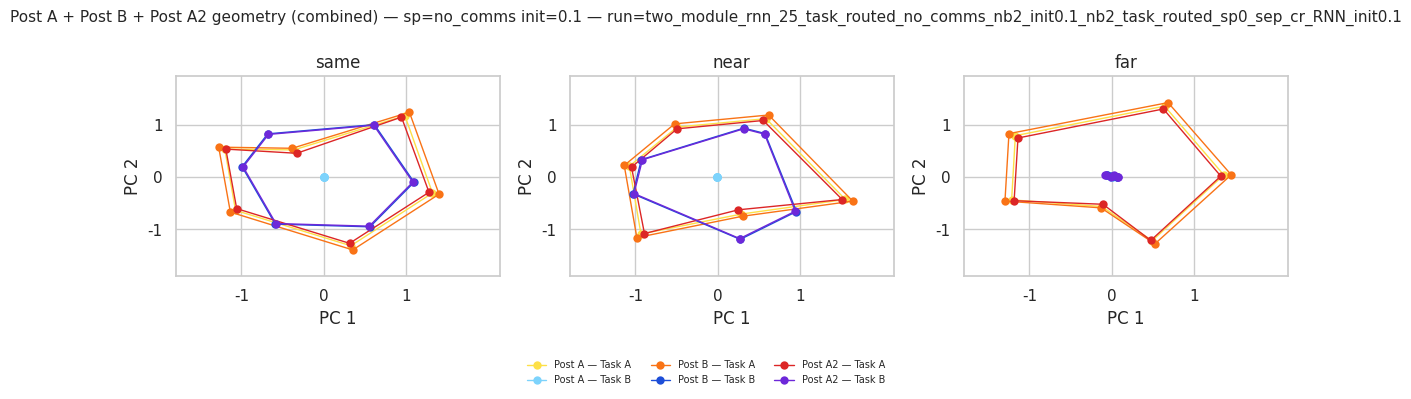

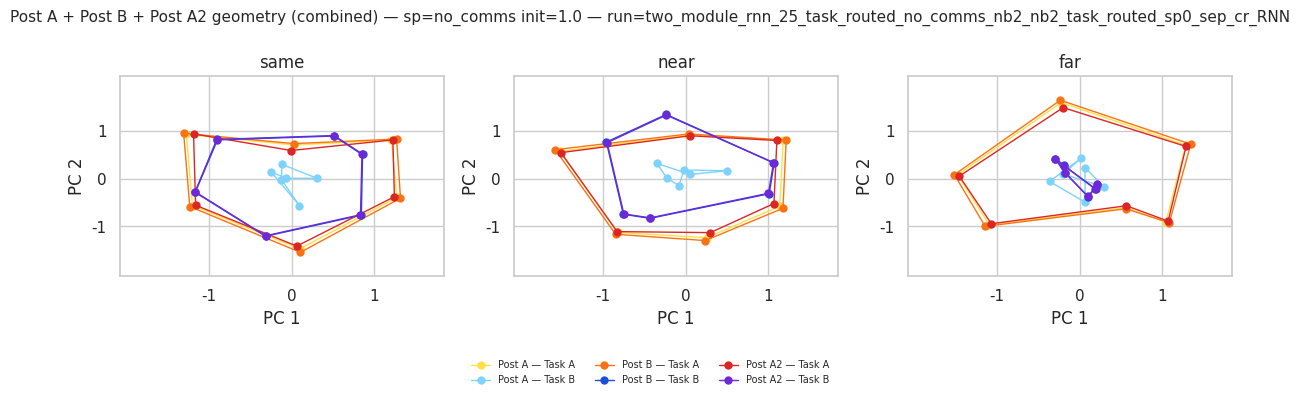

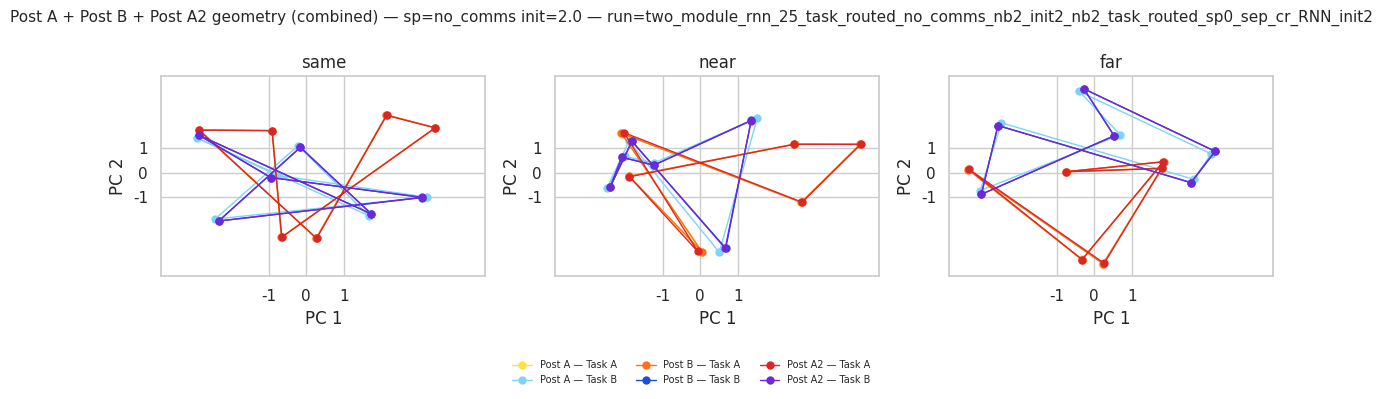

No candidate run found for 0.5 0.001


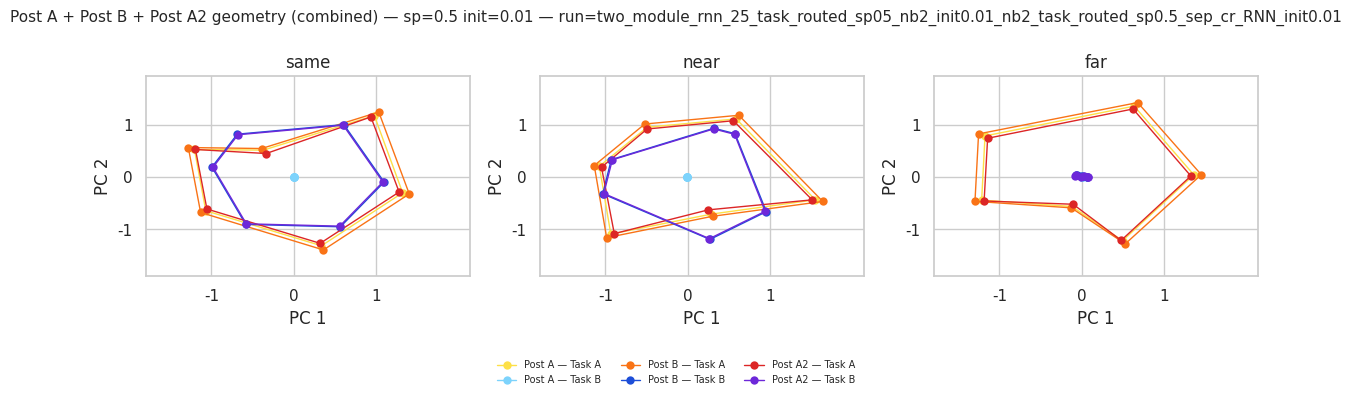

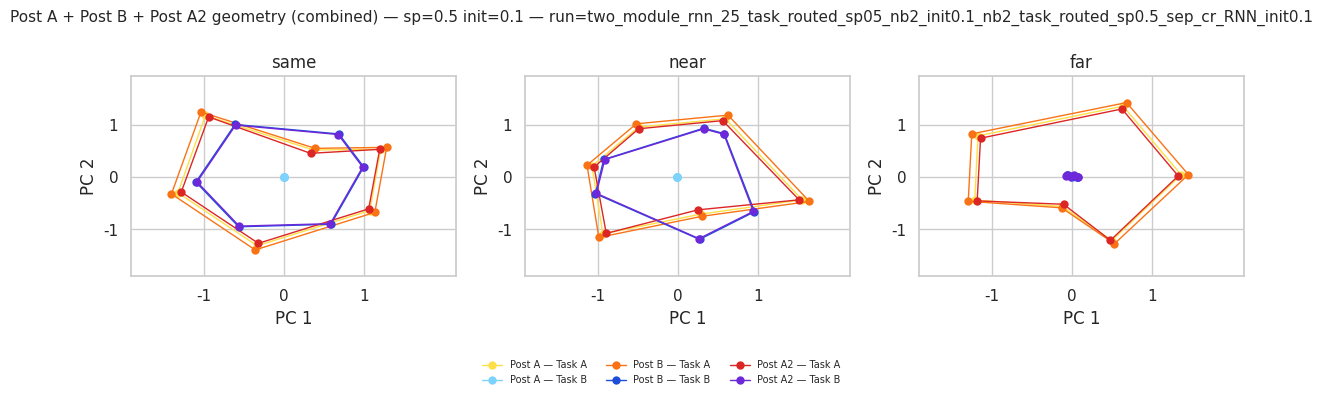

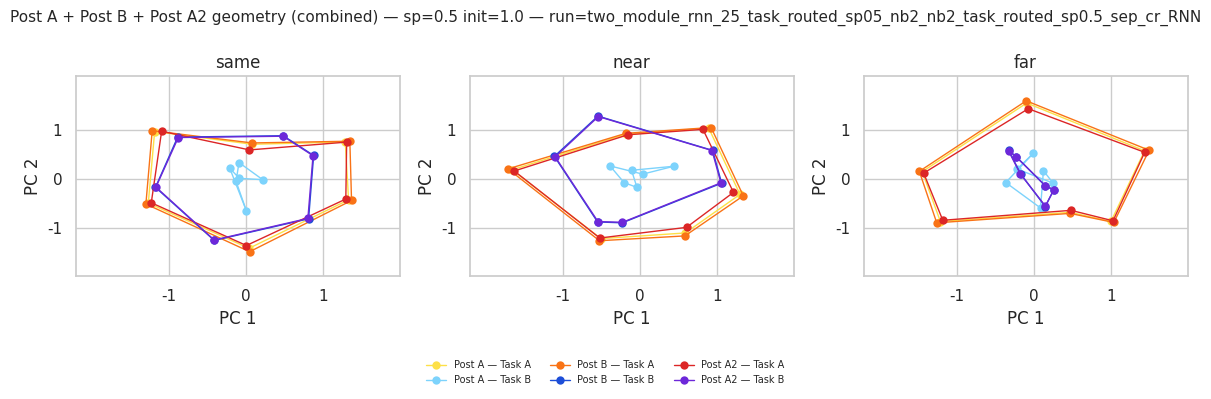

No candidate run found for 0.5 2.0


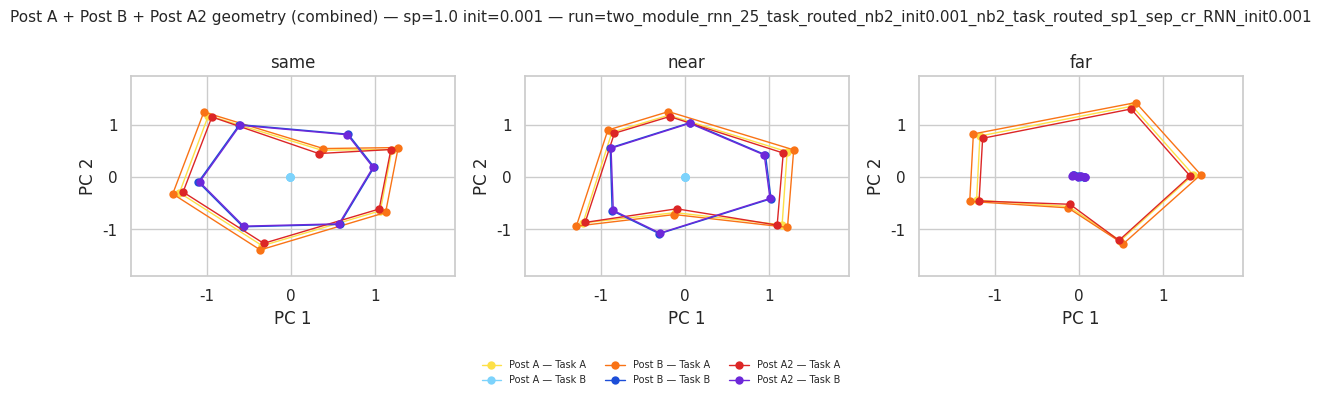

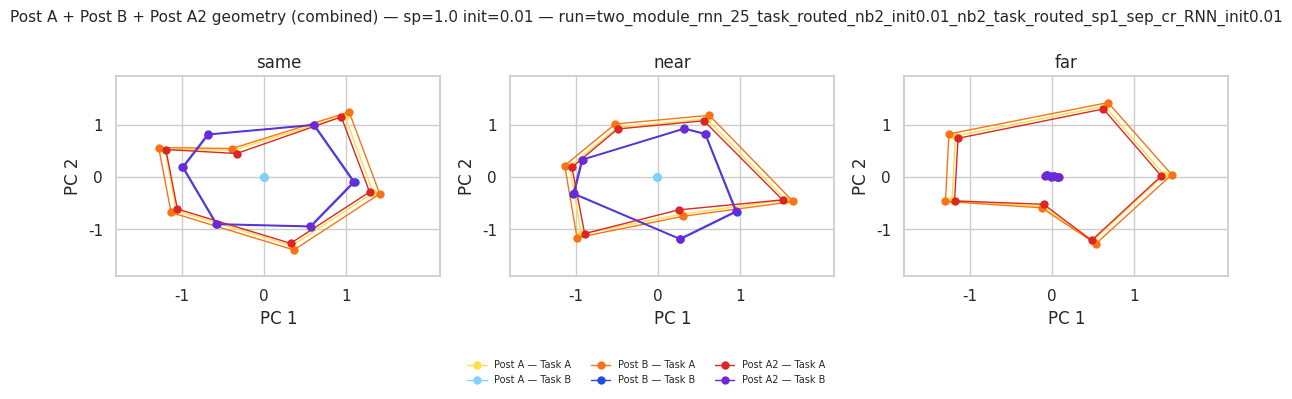

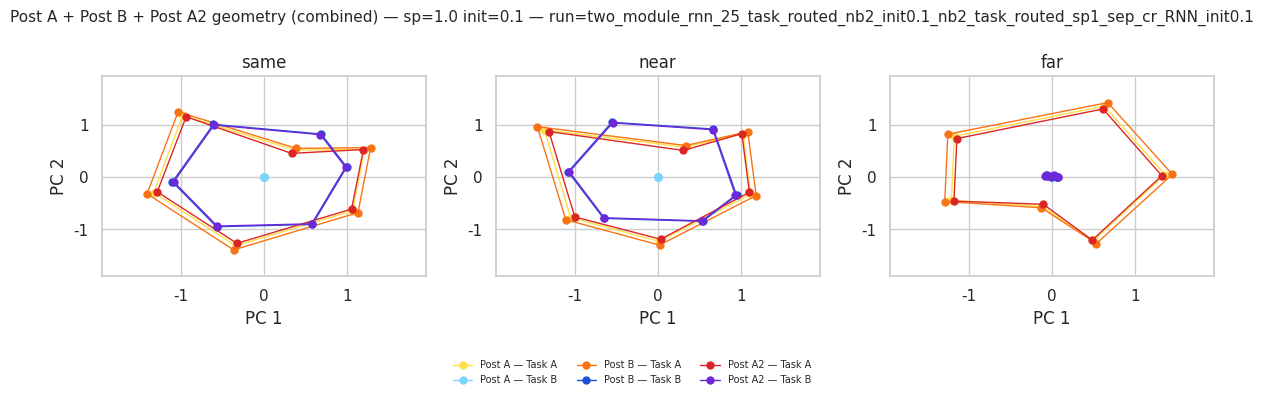

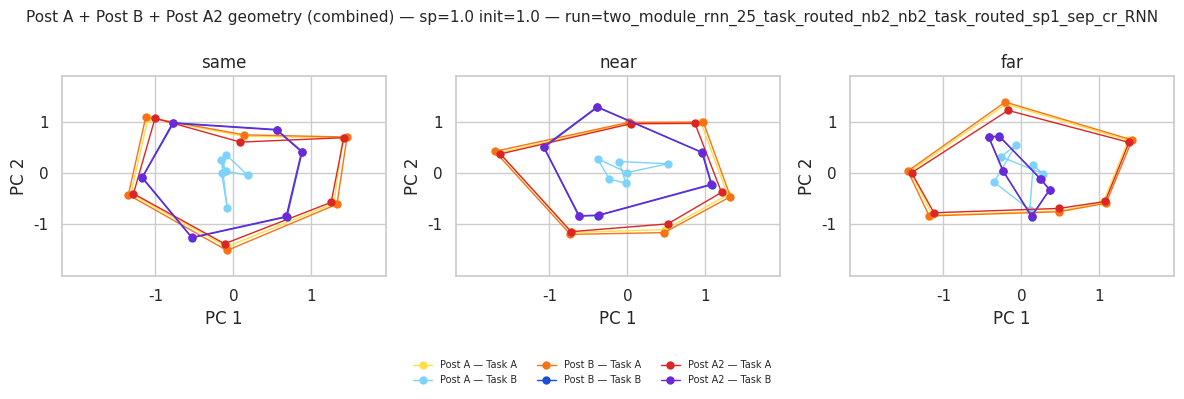

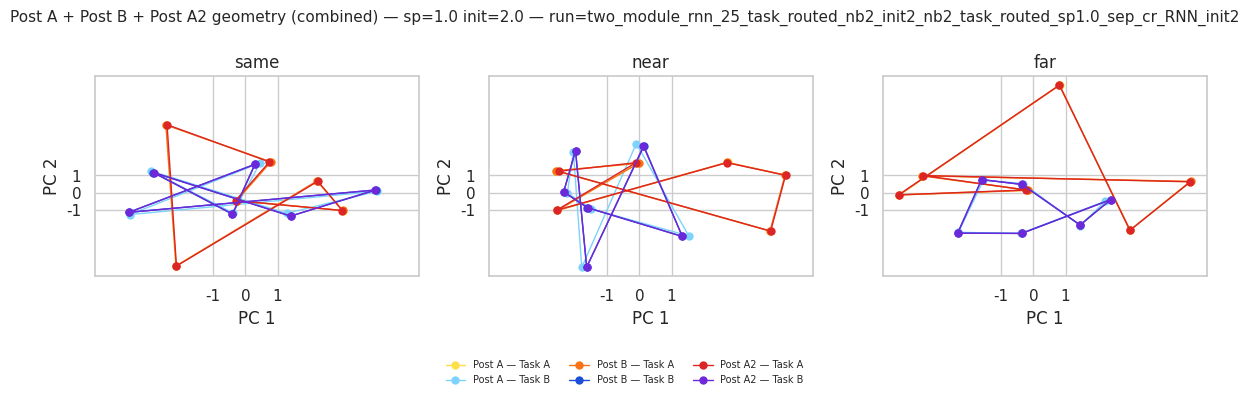

In [27]:
def plot_geometry_snapshot(all_ann_data: dict, target_sp: str, target_init: float, n_stim_plot: int = 12):
    # pick the first run that matches (sp, init)
    candidates = [
        (rid, b) for rid, b in all_ann_data.items()
        if str(b["sparsity_label"]) == str(target_sp) and float(b["init_scale"]) == float(target_init)
    ]
    if not candidates:
        print("No candidate run found for", target_sp, target_init)
        return

    run_id, bundle = candidates[0]
    ann_data = bundle["data"]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(f"Post A + Post B + Post A2 geometry (combined) — sp={target_sp} init={target_init} — run={run_id}", fontsize=11)

    all_triples = []
    for cond in SIMILARITY_ORDER:
        entries = ann_data.get(cond, [])
        if not entries:
            all_triples.append(None)
            continue
        entry = entries[0]
        raw_A = entry.get("hiddens_post_phase_0")
        raw_B = entry.get("hiddens_post_phase_1")
        raw_A2 = entry.get("hiddens_post_phase_2")
        if raw_A is None or raw_B is None or raw_A2 is None:
            all_triples.append(None)
            continue
        h_A = np.asarray(raw_A)
        h_B = np.asarray(raw_B)
        h_A2 = np.asarray(raw_A2)
        if h_A.ndim != 2 or h_B.ndim != 2 or h_A2.ndim != 2:
            all_triples.append(None)
            continue
        if h_A.shape[0] < n_stim_plot or h_B.shape[0] < n_stim_plot or h_A2.shape[0] < n_stim_plot:
            all_triples.append(None)
            continue
        h_A = h_A[:n_stim_plot]
        h_B = h_B[:n_stim_plot]
        h_A2 = h_A2[:n_stim_plot]
        _, X2_A, X2_B, X2_A2 = prepare_pca_shared_three_phase(h_A, h_B, h_A2, n_components=2)
        all_triples.append((X2_A, X2_B, X2_A2))

    flat = []
    for triple in all_triples:
        if triple is not None:
            X2_A, X2_B, X2_A2 = triple
            flat.extend([X2_A, X2_B, X2_A2])
    lims_global = get_axis_limits(np.vstack(flat)) if flat else {}

    for ax, cond, triple in zip(axes, SIMILARITY_ORDER, all_triples):
        if triple is None:
            ax.set_title(f"{cond} (no data)")
            ax.axis("off")
            continue
        X2_A, X2_B, X2_A2 = triple
        plot_split_stim_postA_postB_postA2(ax, X2_A, X2_B, X2_A2, lims_global)
        ax.set_title(cond)

    plt.tight_layout(rect=[0, 0.14, 1, 1])
    for ax in axes:
        hs, ls = ax.get_legend_handles_labels()
        if hs:
            fig.legend(
                hs, ls, loc="lower center", bbox_to_anchor=(0.5, 0.02),
                ncol=3, frameon=False, fontsize=7,
            )
            break
    plt.show()


for target_sp in ["no_comms", "0.5", "1.0"]:
    for init_scale in PAPER_INIT_SCALES:
        plot_geometry_snapshot(all_task, target_sp=target_sp, target_init=float(init_scale))


## Appendix — 3D PCA snapshots

Same as draft.


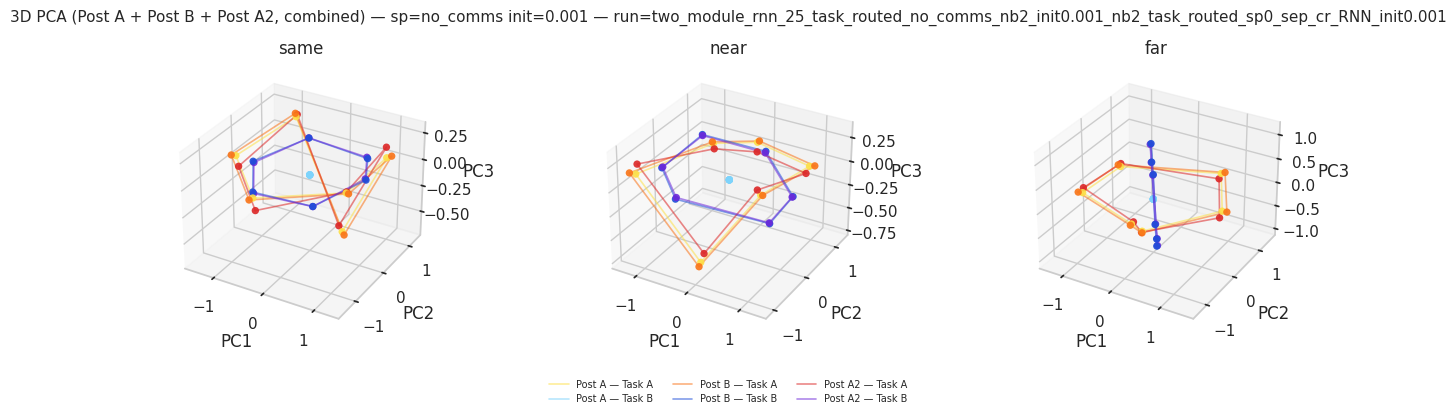

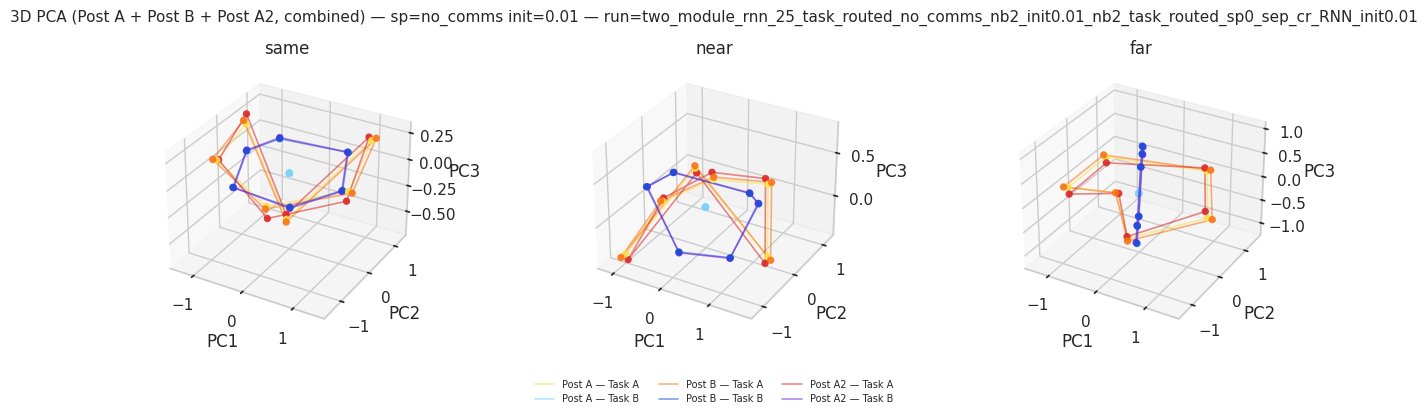

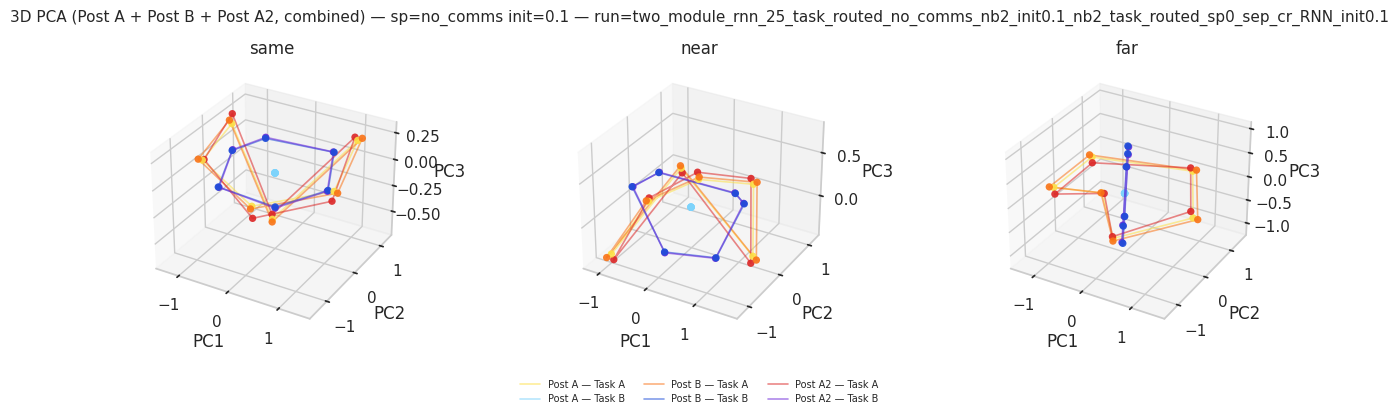

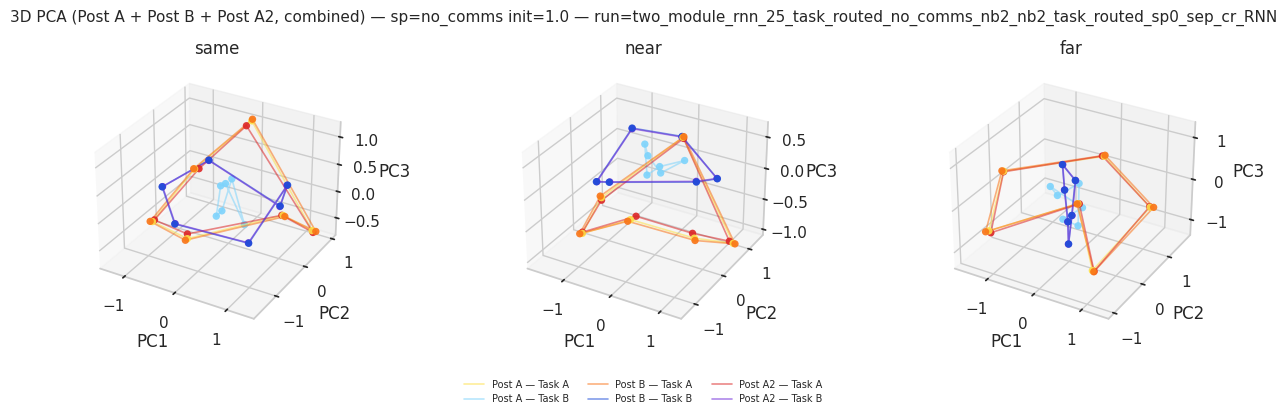

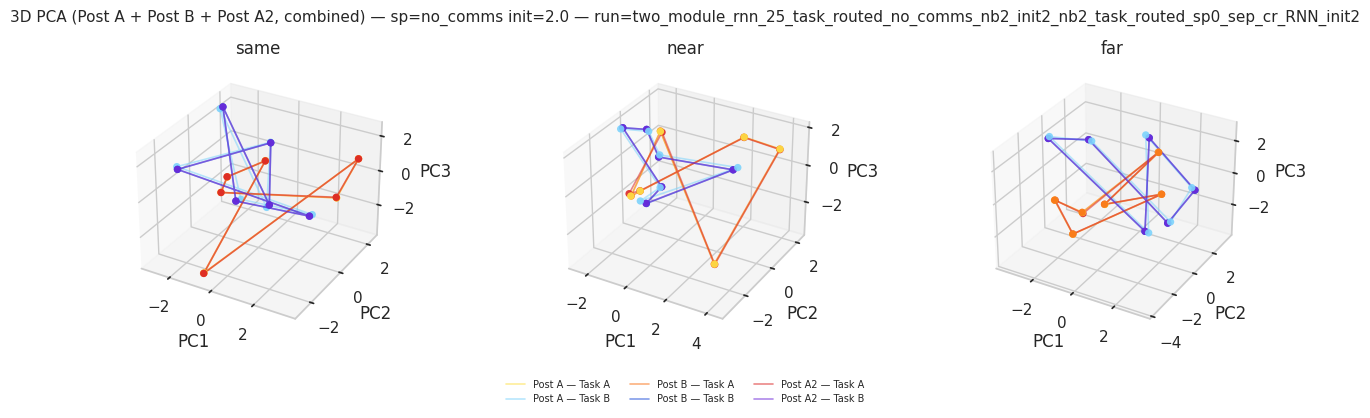

No candidate run found for 0.5 0.001


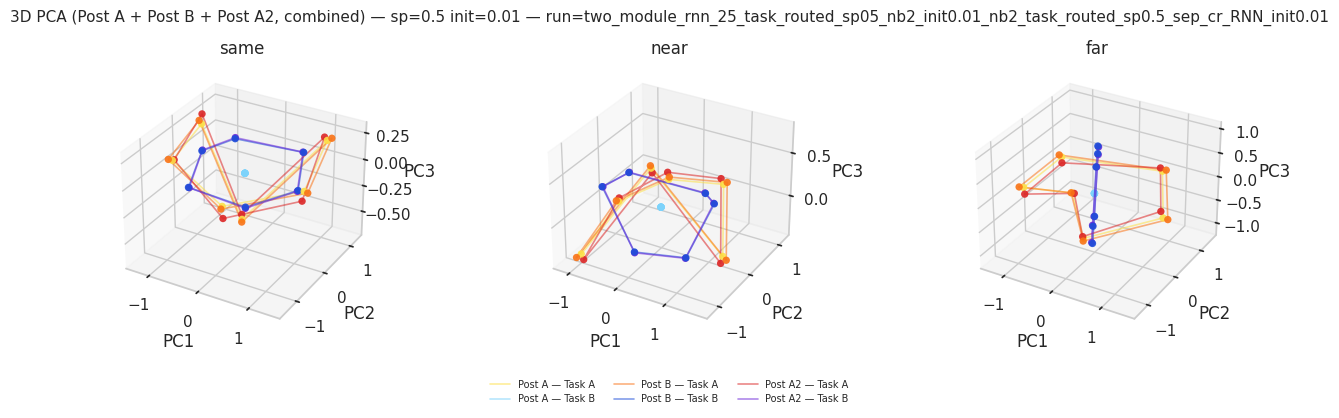

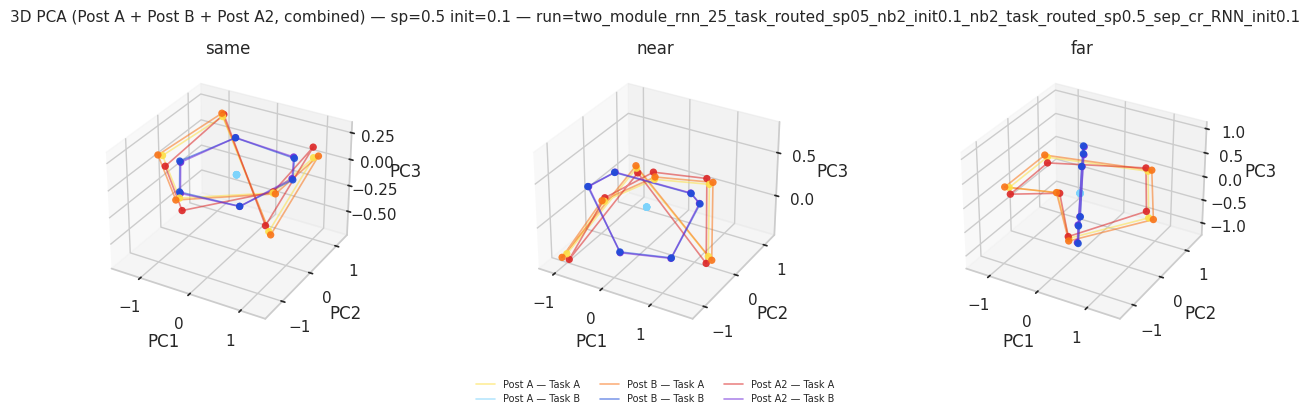

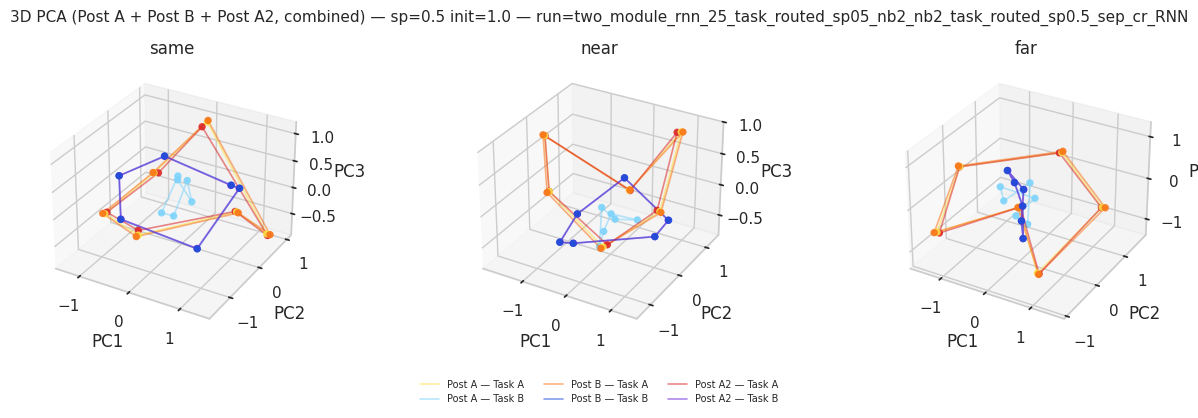

No candidate run found for 0.5 2.0


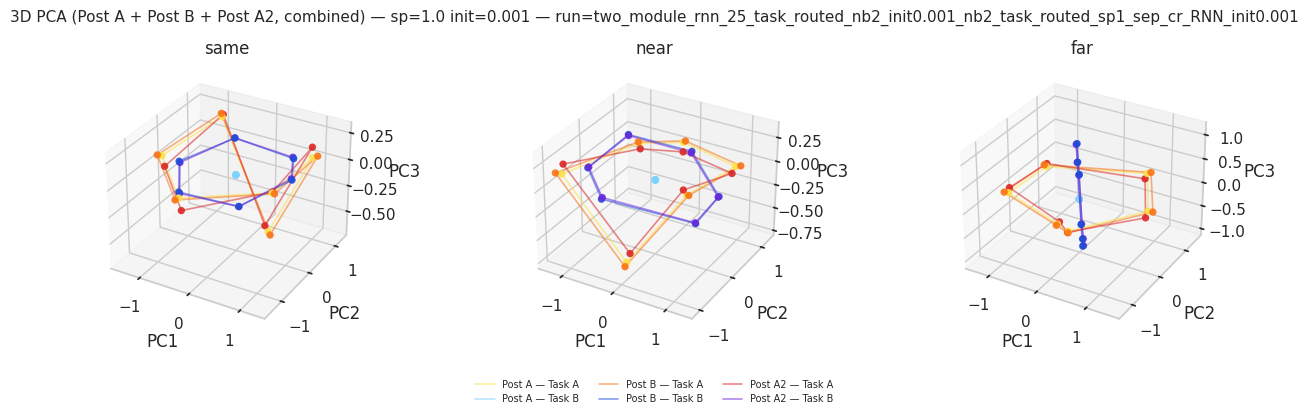

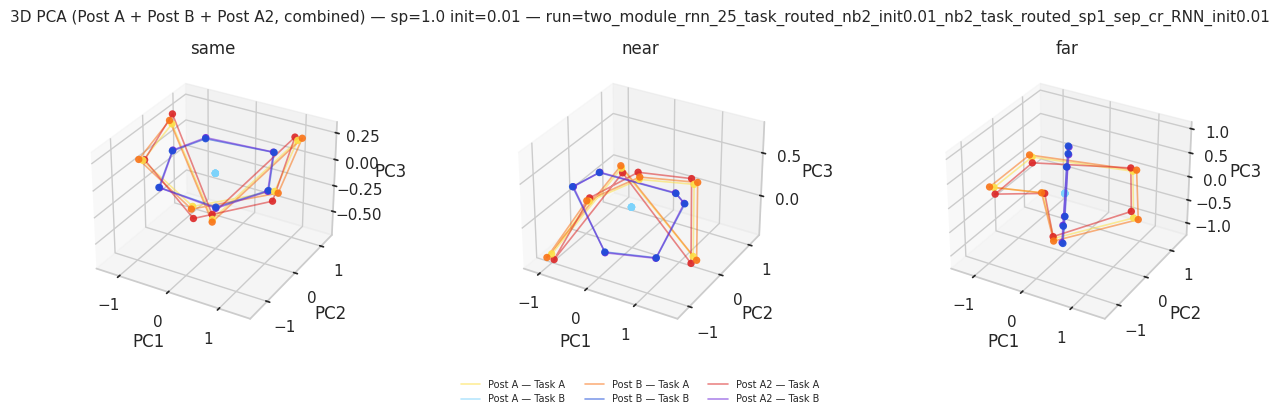

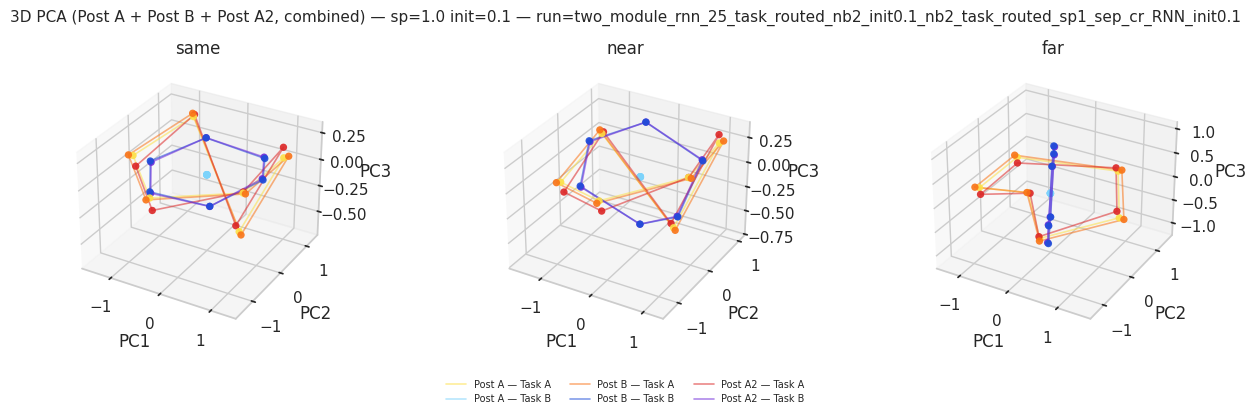

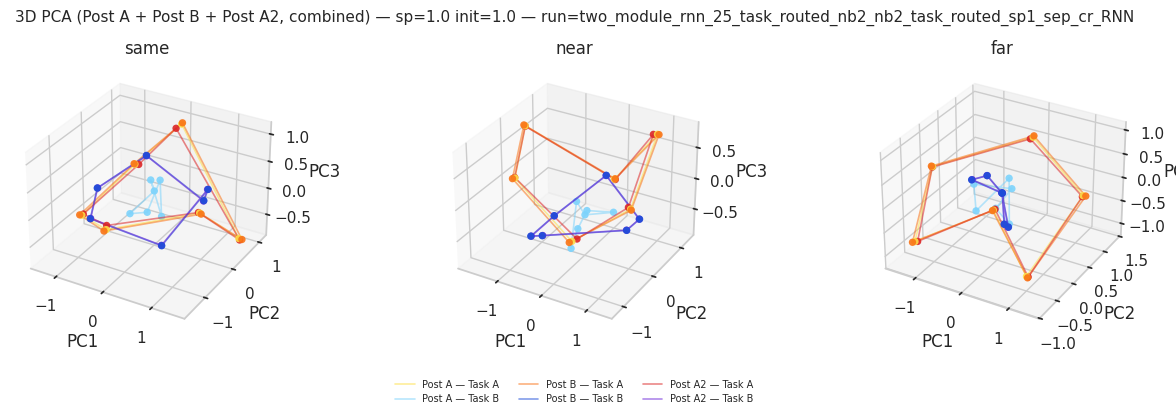

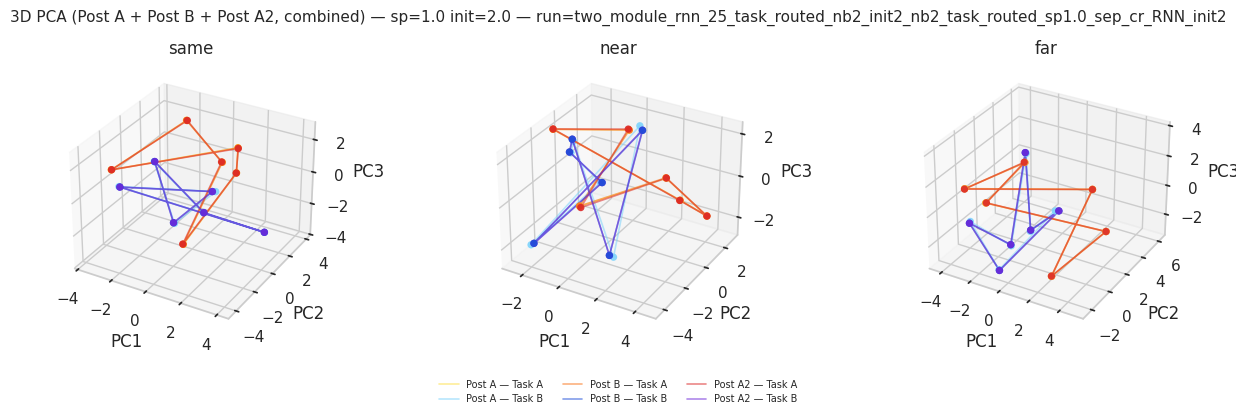

In [28]:
# 3D PCA snapshots (task-routed)
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from a1b2.utils.figure_utils import plot_split_stim_postA_postB_postA2_3d


def plot_geometry_snapshot_3d(all_ann_data: dict, target_sp: str, target_init: float, n_stim_plot: int = 12):
    candidates = [
        (rid, b) for rid, b in all_ann_data.items()
        if str(b["sparsity_label"]) == str(target_sp) and float(b["init_scale"]) == float(target_init)
    ]
    if not candidates:
        print("No candidate run found for", target_sp, target_init)
        return

    run_id, bundle = candidates[0]
    ann_data = bundle["data"]

    fig = plt.figure(figsize=(13, 4.2))
    fig.suptitle(f"3D PCA (Post A + Post B + Post A2, combined) — sp={target_sp} init={target_init} — run={run_id}", fontsize=11)

    legend_handles = None

    for i, cond in enumerate(SIMILARITY_ORDER, start=1):
        ax = fig.add_subplot(1, 3, i, projection="3d")
        entries = ann_data.get(cond, [])
        if not entries:
            ax.set_title(f"{cond} (no data)")
            continue

        entry = entries[0]
        raw_A = entry.get("hiddens_post_phase_0")
        raw_B = entry.get("hiddens_post_phase_1")
        raw_A2 = entry.get("hiddens_post_phase_2")
        if raw_A is None or raw_B is None or raw_A2 is None:
            ax.set_title(f"{cond} (insufficient)")
            continue
        h_A = np.asarray(raw_A)
        h_B = np.asarray(raw_B)
        h_A2 = np.asarray(raw_A2)
        if h_A.ndim != 2 or h_B.ndim != 2 or h_A2.ndim != 2:
            ax.set_title(f"{cond} (insufficient)")
            continue
        if h_A.shape[0] < n_stim_plot or h_B.shape[0] < n_stim_plot or h_A2.shape[0] < n_stim_plot:
            ax.set_title(f"{cond} (insufficient)")
            continue

        h_A = h_A[:n_stim_plot]
        h_B = h_B[:n_stim_plot]
        h_A2 = h_A2[:n_stim_plot]
        _, X3_A, X3_B, X3_A2 = prepare_pca_shared_three_phase(h_A, h_B, h_A2, n_components=3)

        with_leg = legend_handles is None
        h = plot_split_stim_postA_postB_postA2_3d(ax, X3_A, X3_B, X3_A2, labels_for_legend=with_leg)
        if legend_handles is None and h:
            legend_handles = h

        ax.set_title(cond)
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.set_zlabel("PC3")

    if legend_handles:
        fig.legend(
            legend_handles,
            [ln.get_label() for ln in legend_handles],
            loc="lower center",
            bbox_to_anchor=(0.5, 0.02),
            ncol=3,
            frameon=False,
            fontsize=7,
        )

    plt.tight_layout(rect=[0, 0.16, 1, 1])
    plt.show()


for target_sp in ["no_comms", "0.5", "1.0"]:
    for init_scale in PAPER_INIT_SCALES:
        plot_geometry_snapshot_3d(all_task, target_sp=target_sp, target_init=float(init_scale))


## Figure 5 — Routing ablation (task-routed vs shared [+ single])

Transfer: **mean ± SEM** with `errorbar="se"`. Angles: **participant-level** `catplot` with SEM (not mean-only aggregates).


/tmp/ipykernel_3438060/2599632691.py:59: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_3438060/2599632691.py:59: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_3438060/2599632691.py:59: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_3438060/2599632691.py:59: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib

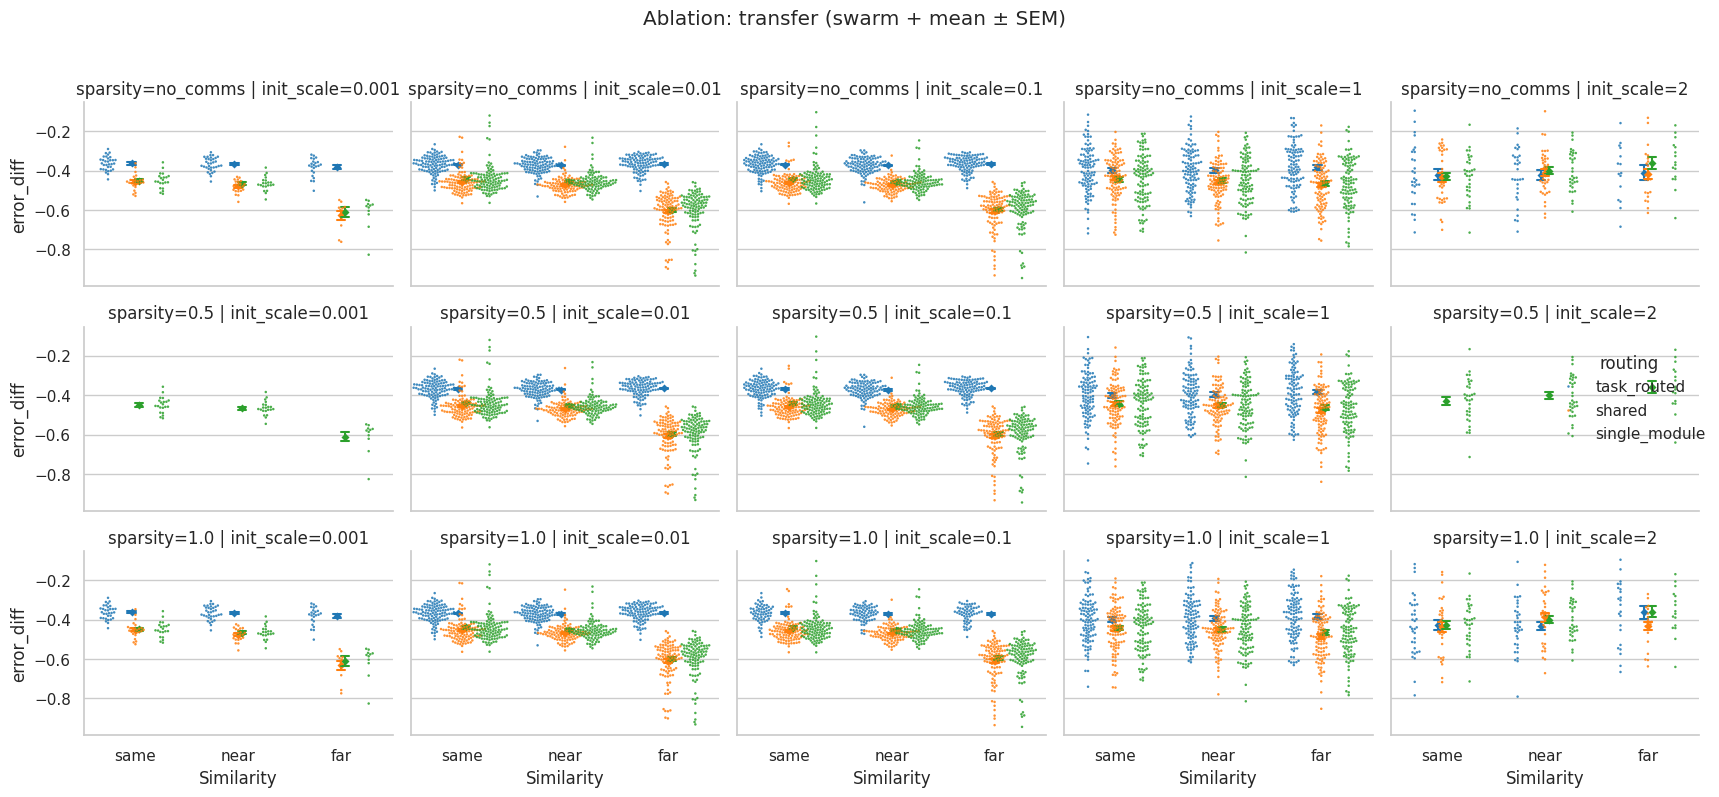

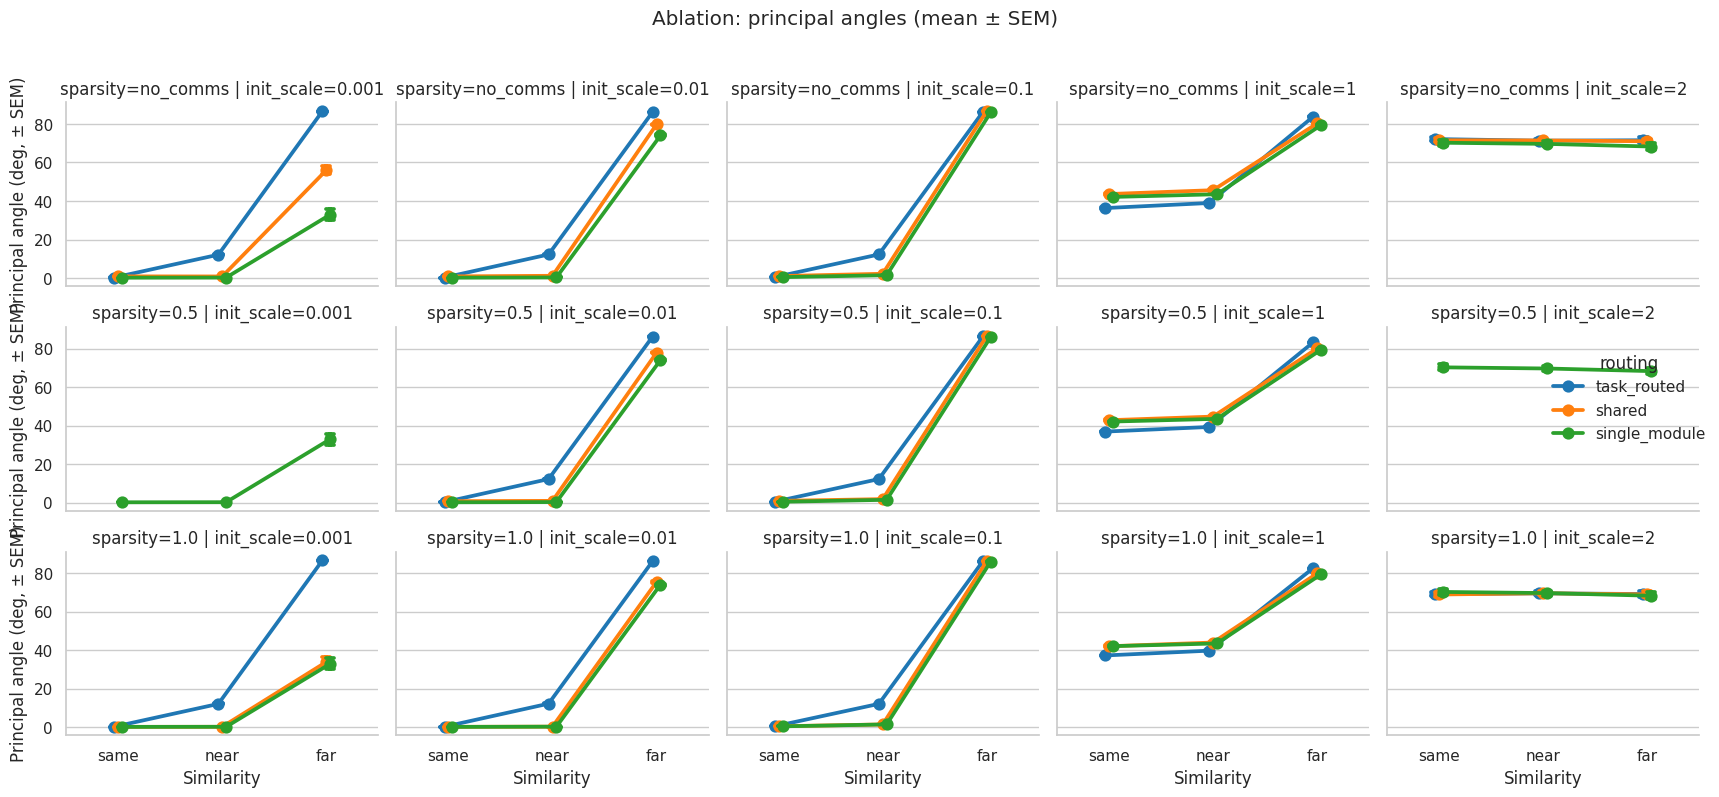

In [29]:
def add_routing_label(df: pd.DataFrame, routing: str):
    if df is None or df.empty:
        return pd.DataFrame()
    out = df.copy()
    out["routing"] = routing
    return out


facet_sp_order = [s for s in PAPER_SPARSITIES if s in SPARSITY_ORDER]
tr_single_x = broadcast_baseline_sparsity(transfer_single, facet_sp_order)
ang_single_x = broadcast_baseline_sparsity(angles_single, facet_sp_order)

_parts_tr = [
    add_routing_label(transfer_task, "task_routed"),
    add_routing_label(transfer_shared, "shared"),
]
if not tr_single_x.empty:
    _parts_tr.append(add_routing_label(tr_single_x, "single_module"))
tr_both = pd.concat(_parts_tr, ignore_index=True)

_parts_ang = [
    add_routing_label(angles_task, "task_routed"),
    add_routing_label(angles_shared, "shared"),
]
if not ang_single_x.empty:
    _parts_ang.append(add_routing_label(ang_single_x, "single_module"))
ang_both = pd.concat(_parts_ang, ignore_index=True)

if not tr_both.empty:
    g = sns.catplot(
        data=tr_both,
        x="condition",
        y="error_diff",
        hue="routing",
        col="init_scale",
        row="sparsity_label",
        col_order=init_order,
        row_order=sp_order,
        kind="swarm",
        dodge=True,
        order=SIMILARITY_ORDER,
        hue_order=ROUTING_HUE_ORDER,
        palette=ROUTING_PALETTE,
        size=1.8,
        linewidth=0,
        alpha=0.85,
        height=2.6,
        aspect=1.2,
    )
    for i, row_name in enumerate(sp_order):
        for j, col_name in enumerate(init_order):
            ax = g.axes[i, j]
            sub = tr_both[
                (tr_both["sparsity_label"] == row_name)
                & (tr_both["init_scale"] == col_name)
            ]
            if sub.empty:
                continue
            sns.pointplot(
                data=sub,
                x="condition",
                y="error_diff",
                hue="routing",
                order=SIMILARITY_ORDER,
                hue_order=ROUTING_HUE_ORDER,
                palette=ROUTING_PALETTE,
                dodge=True,
                ax=ax,
                errorbar="se",
                capsize=0.08,
                markers="D",
                linestyles="",
                scale=0.55,
                legend=False,
            )
    g.set_axis_labels("Similarity", "error_diff")
    g.set_titles(row_template="sparsity={row_name}", col_template="init_scale={col_name}")
    g.fig.suptitle("Ablation: transfer (swarm + mean ± SEM)", y=1.02)
    plt.tight_layout()
    plt.show()

if not ang_both.empty:
    ang_both["init_scale"] = ang_both["init_scale"].astype(float)
    g = sns.catplot(
        data=ang_both,
        x="condition",
        y="principal_angle_between",
        hue="routing",
        col="init_scale",
        row="sparsity_label",
        col_order=init_order,
        row_order=sp_order,
        kind="point",
        dodge=True,
        order=SIMILARITY_ORDER,
        hue_order=ROUTING_HUE_ORDER,
        palette=ROUTING_PALETTE,
        height=2.6,
        aspect=1.2,
        errorbar="se",
        capsize=0.08,
    )
    g.set_axis_labels("Similarity", "Principal angle (deg, ± SEM)")
    g.set_titles(row_template="sparsity={row_name}", col_template="init_scale={col_name}")
    g.fig.suptitle("Ablation: principal angles (mean ± SEM)", y=1.02)
    plt.tight_layout()
    plt.show()


## Appendix — Paper-faithful transfer (same `error_diff` construction)

Matches `PAPER_FAITHFUL_TESTING_PROTOCOL.md` (winter `1::2`, k=6). **SEM** across participants.


/tmp/ipykernel_3438060/3851595979.py:49: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_3438060/3851595979.py:49: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_3438060/3851595979.py:49: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_3438060/3851595979.py:49: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib

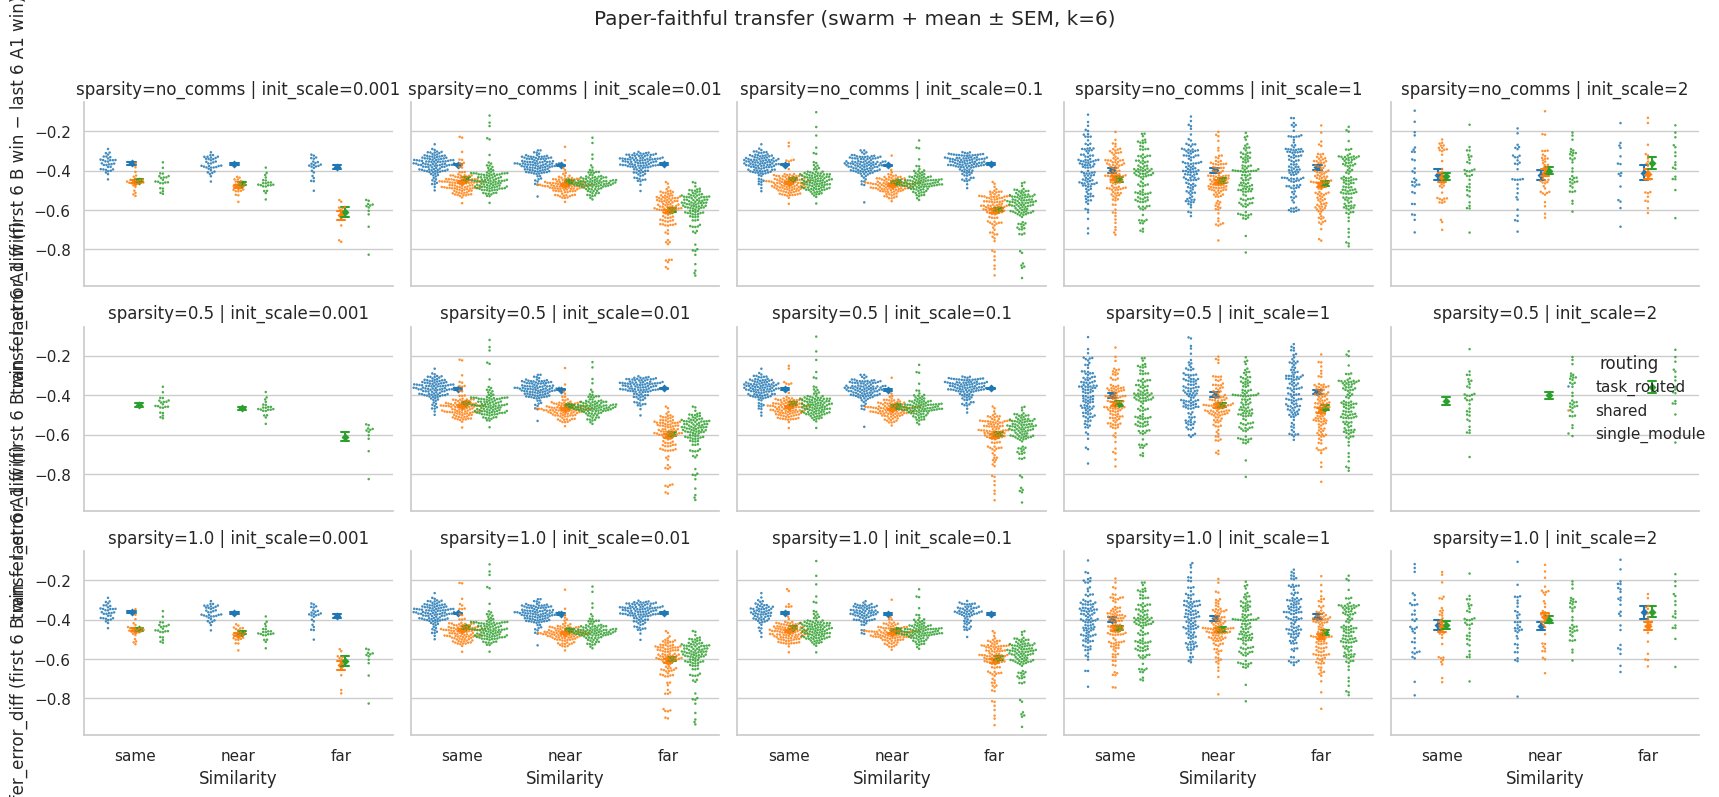

In [30]:
facet_sp = [s for s in PAPER_SPARSITIES if s in SPARSITY_ORDER]
tr_single_f = broadcast_baseline_sparsity(transfer_single, facet_sp)
protocol_tr = pd.concat(
    [
        add_routing_label(transfer_task, "task_routed"),
        add_routing_label(transfer_shared, "shared"),
        add_routing_label(tr_single_f, "single_module"),
    ],
    ignore_index=True,
)

if not protocol_tr.empty:
    sub = protocol_tr[
        protocol_tr["init_scale"].isin(PAPER_INIT_SCALES)
        & protocol_tr["sparsity_label"].isin(PAPER_SPARSITIES)
    ].copy()

    g = sns.catplot(
        data=sub,
        x="condition",
        y="error_diff",
        hue="routing",
        col="init_scale",
        row="sparsity_label",
        col_order=PAPER_INIT_SCALES,
        row_order=PAPER_SPARSITIES,
        kind="swarm",
        dodge=True,
        order=SIMILARITY_ORDER,
        hue_order=ROUTING_HUE_ORDER,
        palette=ROUTING_PALETTE,
        size=1.8,
        linewidth=0,
        alpha=0.85,
        height=2.6,
        aspect=1.2,
    )
    facet_sp = list(PAPER_SPARSITIES)
    facet_init = list(PAPER_INIT_SCALES)
    for i, row_name in enumerate(facet_sp):
        for j, col_name in enumerate(facet_init):
            ax = g.axes[i, j]
            s2 = sub[
                (sub["sparsity_label"] == row_name)
                & (sub["init_scale"] == col_name)
            ]
            if s2.empty:
                continue
            sns.pointplot(
                data=s2,
                x="condition",
                y="error_diff",
                hue="routing",
                order=SIMILARITY_ORDER,
                hue_order=ROUTING_HUE_ORDER,
                palette=ROUTING_PALETTE,
                dodge=True,
                ax=ax,
                errorbar="se",
                capsize=0.08,
                markers="D",
                linestyles="",
                scale=0.55,
                legend=False,
            )
    g.set_axis_labels("Similarity", "transfer_error_diff (first 6 B win − last 6 A1 win)")
    g.set_titles(row_template="sparsity={row_name}", col_template="init_scale={col_name}")
    g.fig.suptitle("Paper-faithful transfer (swarm + mean ± SEM, k=6)", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No rows for paper-faithful transfer (error_diff).")
